# QM640 Capstone — Complexity-Adaptive Multi-Agent Collaboration for Medical Diagnosis
**Evaluating Task Routing and Performance in LLM-Based Systems**

Ajay Srinivasan Krishnan · Walsh College MS in Data Analytics · Summer 2026

---
## Notebook Structure
| Section | Content |
|---|---|
| 0 | Environment setup & configuration |
| 1 | Data acquisition & preprocessing |
| 2 | Complexity feature engineering |
| 3 | Multi-agent system implementation |
| 4 | Inference runs (baseline + adaptive) |
| 5 | Statistical analysis — RQ1 & RQ3 |
| 6 | Statistical analysis — RQ2 |
| 7 | ML models — RQ1, RQ2, RQ3, RQ4 |
| 8 | SHAP interpretability |
| 9 | Results summary & publication figures |

---
## Section 0 — Environment Setup

In [3]:
import subprocess, sys
# Install required packages (run once)
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "datasets", "anthropic", "openai", "pandas", "numpy", "scipy", "scikit-learn", "shap", "matplotlib", "seaborn", "pingouin", "statsmodels", "tqdm", "requests", "pyarrow", "openpyxl", "huggingface_hub", "rank_bm25", "rapidfuzz", "python-dotenv", "langgraph", "pyathena"
])
# Optional: scispaCy NER model (~500 MB) — improves symptom/condition extraction.
# Requires Python <=3.12; NOT compatible with Python 3.13+.
# On Python 3.13+ the regex fallback in src/preprocessing.py activates automatically.
# Uncomment only on Python <=3.12:
subprocess.check_call([sys.executable, "-m", "pip", "install", "scispacy"])
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz"])


  Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.2.5 requires numpy<2.0.0,>=1.19.0; python_version >= "3.9", but you have numpy 2.4.4 which is incompatible.
scispacy 0.6.2 requires numpy<2.0, but you have numpy 2.4.4 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: /Users/ajaykrishnan/.pyenv/versions/3.11.14/bin/python -m pip install --upgrade pip


  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: /Users/ajaykrishnan/.pyenv/versions/3.11.14/bin/python -m pip install --upgrade pip


  Using cached https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz (14.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: /Users/ajaykrishnan/.pyenv/versions/3.11.14/bin/python -m pip install --upgrade pip


0

In [5]:
import sys, os
from pathlib import Path

# VS Code sets __vsc_ipynb_file__ to the notebook absolute path
try:
    _root = str(Path(__vsc_ipynb_file__).parent)
except NameError:
    # Fallback: walk up from CWD until we find the dir with src/
    _cwd = Path.cwd()
    _root = next(
        (str(p) for p in [_cwd] + list(_cwd.parents) if (p / 'src').is_dir()),
        str(_cwd)
    )

if _root not in sys.path:
    sys.path.insert(0, _root)
print(f'Project root: {_root}')
print(f'src exists: {(Path(_root) / "src").is_dir()}')

from src.llm_client import (
    LLMClient, get_test_client,
    TEST_BACKEND, OLLAMA_MODEL, OLLAMA_BASE_URL,
)
from src.token_tracker import TokenTracker
from src.database import ResultsDB
from src.agents import (adaptive_router, run_single_agent,
                         run_static_multi_agent, run_adaptive_multi_agent,
                         safe_acc_per_1k, MedQAKnowledgeRetriever)
from src.evaluator import answer_is_correct
from src.preprocessing import compute_complexity_features

# TEST_BACKEND = 'haiku'   uses claude-haiku-4-5-20251001 (Anthropic)
# TEST_BACKEND = 'ollama'  uses OLLAMA_MODEL at OLLAMA_BASE_URL (local)
print(f'src modules loaded ✓  |  TEST_BACKEND={TEST_BACKEND!r}', end='')
if TEST_BACKEND == 'ollama':
    print(f'  OLLAMA_MODEL={OLLAMA_MODEL!r}  OLLAMA_BASE_URL={OLLAMA_BASE_URL!r}', end='')
print()


Project root: /Users/ajaykrishnan/Documents/Claude/Claude code
src exists: True
src modules loaded ✓  |  TEST_BACKEND='haiku'


In [6]:
import os, json, re, time, hashlib, warnings, random
from pathlib import Path
from copy import deepcopy
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Stats
from scipy import stats
from scipy.stats import wilcoxon, mannwhitneyu, f_oneway, levene
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg

# ML
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score)
import shap

# Viz
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print('Environment ready.')

/Users/ajaykrishnan/.pyenv/versions/3.11.14/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment ready.


In [7]:
from dotenv import load_dotenv
# override=True forces reload of updated .env values even if the kernel
# already has stale copies of these variables in os.environ
_env_path = Path(_root) / '.env'
load_dotenv(_env_path, override=True)
print(f'.env loaded from {_env_path}')
# Confirm AWS variables are visible (masks values for safety)
_aws_key = os.getenv('AWS_ACCESS_KEY_ID', '')
print(f'  AWS_ACCESS_KEY_ID  : {_aws_key[:8]}... ({"set" if _aws_key and _aws_key != "YOUR_AWS_ACCESS_KEY_ID" else "PLACEHOLDER — update .env"})')
_s3_out = os.getenv('S3_ATHENA_OUTPUT', '')
print(f'  S3_ATHENA_OUTPUT   : {_s3_out}')

.env loaded from /Users/ajaykrishnan/Documents/Claude/Claude code/.env
  AWS_ACCESS_KEY_ID  : AKIA47CR... (set)
  S3_ATHENA_OUTPUT   : s3://aws-glue-assets-891377282702-us-east-1/athena-output/


In [8]:
# ─── Configuration ────────────────────────────────────────────────────────────
USE_REAL_API = True

OPENAI_API_KEY    = os.getenv('OPENAI_API_KEY',    'YOUR_OPENAI_KEY')
ANTHROPIC_API_KEY = os.getenv('ANTHROPIC_API_KEY', 'YOUR_ANTHROPIC_KEY')

# Sample sizes
DDXPLUS_SAMPLE   = 5_000   # stratified from 1.3 M
MEDQA_SAMPLE     = 1_273   # 10 % of 12,733
MMLU_SAMPLE      = 400     # all four medical sub-categories
INFERENCE_SAMPLE = 1_000   # 334 Simple + 333 Moderate + 333 Complex (equal-tier)

# Routing / complexity tiers
ROUTING_TIERS    = ['solo', 'group-2', 'group-3', 'MDT']
COMPLEXITY_TIERS = ['Simple', 'Moderate', 'Complex']
AGENT_CONFIGS    = ['single-agent', 'static_multi-agent', 'adaptive']
LLM_BACKENDS     = ['Claude-Haiku', 'GPT-4o', 'GPT-4o-mini', 'Claude-Sonnet', 'Llama-3.3-70B']

DATA_DIR   = Path(_root) / 'data'
OUTPUT_DIR = Path(_root) / 'outputs'
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'USE_REAL_API = {USE_REAL_API}')
print(f'INFERENCE_SAMPLE = {INFERENCE_SAMPLE}')


USE_REAL_API = True
INFERENCE_SAMPLE = 1000


In [9]:
# ── Table 2: Estimated API Cost by LLM Backbone (synopsis §4.1) ─────────────
# Based on a 5,000-query DDXPlus sample with ~1,500 tokens/query
_cost_rows = [
    {'LLM Model':            'GPT-4o',
     'Est. Tokens/Query':    '~1,500',
     'Sample n':             5_000,
     'Cost/1K Tokens ($)':   0.005,
     'Total Est. Cost ($)':  round(0.005 * 1.5 * 5_000, 2)},
    {'LLM Model':            'GPT-4o-mini',
     'Est. Tokens/Query':    '~1,500',
     'Sample n':             5_000,
     'Cost/1K Tokens ($)':   0.00015,
     'Total Est. Cost ($)':  round(0.00015 * 1.5 * 5_000, 2)},
    {'LLM Model':            'Claude Sonnet 4.6',
     'Est. Tokens/Query':    '~1,500',
     'Sample n':             5_000,
     'Cost/1K Tokens ($)':   0.003,
     'Total Est. Cost ($)':  round(0.003 * 1.5 * 5_000, 2)},
    {'LLM Model':            'Claude Haiku 4.5',
     'Est. Tokens/Query':    '~1,500',
     'Sample n':             5_000,
     'Cost/1K Tokens ($)':   0.00025,
     'Total Est. Cost ($)':  round(0.00025 * 1.5 * 5_000, 2)},
    {'LLM Model':            'Llama-3.3-70B (local)',
     'Est. Tokens/Query':    '~1,500',
     'Sample n':             5_000,
     'Cost/1K Tokens ($)':   0.0,
     'Total Est. Cost ($)':  0.0},
]
table2 = pd.DataFrame(_cost_rows)
print("Table 2: Estimated API Cost by LLM Backbone (5,000-query DDXPlus sample)")
print(table2.to_string(index=False))
del _cost_rows


Table 2: Estimated API Cost by LLM Backbone (5,000-query DDXPlus sample)
            LLM Model Est. Tokens/Query  Sample n  Cost/1K Tokens ($)  Total Est. Cost ($)
               GPT-4o            ~1,500      5000             0.00500                37.50
          GPT-4o-mini            ~1,500      5000             0.00015                 1.12
    Claude Sonnet 4.6            ~1,500      5000             0.00300                22.50
     Claude Haiku 4.5            ~1,500      5000             0.00025                 1.88
Llama-3.3-70B (local)            ~1,500      5000             0.00000                 0.00


In [10]:
# ── Patch 14: Simulation validity gate ──
# REPORTING_VALID is True only when running with real API calls.
# When False, all statistical results are based on simulated data and
# should NOT be treated as empirical findings.
REPORTING_VALID = USE_REAL_API

if not REPORTING_VALID:
    import warnings
    warnings.warn(
        "REPORTING_VALID=False: notebook is running in simulation mode. "
        "All reported statistics are based on synthetic data. "
        "Set USE_REAL_API=True and re-run for publication-quality results.",
        UserWarning, stacklevel=2
    )
    print("=" * 70)
    print("SIMULATION MODE: results below are NOT empirical findings.")
    print("Set USE_REAL_API=True for real-API results.")
    print("=" * 70)
else:
    print("REPORTING_VALID=True: running with live API calls.")

REPORTING_VALID=True: running with live API calls.


---
## Section 1 — Data Acquisition & Preprocessing

### 1.1 MedQA (USMLE)

In [11]:
def load_medqa(sample_n: Optional[int] = None, seed: int = SEED) -> pd.DataFrame:
    """Load MedQA USMLE-4-options from HuggingFace Hub."""
    from datasets import load_dataset
    ds = load_dataset('GBaker/MedQA-USMLE-4-options', split='test')
    df = ds.to_pandas()

    # Normalize columns
    df = df.rename(columns={'question': 'clinical_vignette',
                             'answer': 'correct_answer'})
    df['question_id']    = 'MEDQA_' + df.index.astype(str)
    df['dataset_source'] = 'MedQA'

    if sample_n:
        df = df.sample(n=min(sample_n, len(df)), random_state=seed).reset_index(drop=True)

    return df[['question_id', 'dataset_source', 'clinical_vignette', 'correct_answer']]


if USE_REAL_API:
    medqa_df = load_medqa(sample_n=MEDQA_SAMPLE)
    print(f'MedQA loaded: {len(medqa_df):,} rows')
else:
    print('Skipping live download — will use simulated dataset in Section 1.6')

MedQA loaded: 1,273 rows


### 1.2 DDXPlus

In [12]:
def load_ddxplus(sample_n: int = DDXPLUS_SAMPLE, seed: int = SEED) -> pd.DataFrame:
    """
    Load DDXPlus patient profiles.
    Repo: https://github.com/mila-iqia/ddxplus
    Expected local path: data/ddxplus/release_train_patients.csv
    """
    csv_path = DATA_DIR / 'ddxplus' / 'release_train_patients.csv'
    if not csv_path.exists():
        raise FileNotFoundError(
            f'{csv_path} not found.\n'
            'Clone https://github.com/mila-iqia/ddxplus and place CSV files under data/ddxplus/'
        )

    df = pd.read_csv(csv_path)

    # Key columns: AGE, SEX, PATHOLOGY, EVIDENCES, DIFFERENTIAL_DIAGNOSIS
    df['clinical_vignette'] = df.apply(
        lambda r: (
            f"Patient: {r.get('AGE','?')}y {r.get('SEX','?')}. "
            f"Symptoms: {r.get('EVIDENCES', '')}.\n"
            f"Differential: {r.get('DIFFERENTIAL_DIAGNOSIS', '')}"
        ), axis=1
    )
    df['correct_answer']  = df['PATHOLOGY']
    df['question_id']     = 'DDXPLUS_' + df.index.astype(str)
    df['dataset_source']  = 'DDXPlus'
    df['num_symptoms']    = df['EVIDENCES'].apply(
        lambda x: len(str(x).split(',')) if pd.notna(x) else 0
    )
    df['num_conditions']  = df['DIFFERENTIAL_DIAGNOSIS'].apply(
        lambda x: len(str(x).split(',')) if pd.notna(x) else 1
    )

    # Stratified sample across PATHOLOGY
    strata = df['PATHOLOGY'].value_counts(normalize=True)
    sample_counts = (strata * sample_n).round().astype(int)
    sample_counts = sample_counts.clip(lower=1)
    frames = [
        df[df['PATHOLOGY'] == cat].sample(
            n=min(n, (df['PATHOLOGY'] == cat).sum()), random_state=seed
        )
        for cat, n in sample_counts.items()
    ]
    df = pd.concat(frames).sample(frac=1, random_state=seed).reset_index(drop=True)

    return df[['question_id', 'dataset_source', 'clinical_vignette',
               'correct_answer', 'num_symptoms', 'num_conditions']]


if USE_REAL_API:
    ddxplus_df = load_ddxplus()
    print(f'DDXPlus loaded: {len(ddxplus_df):,} rows')
else:
    print('Skipping live download — will use simulated dataset in Section 1.6')

DDXPlus loaded: 5,006 rows


### 1.3 MedAgentsBench

In [13]:
def load_medagentsbench() -> pd.DataFrame:
    """Load MedAgentsBench from HuggingFace (super-dainiu/MedAgentsBench).
    Loads all 10 medical QA configs, test split.
    """
    from datasets import load_dataset

    configs = [
        'AfrimedQA', 'MMLU-Pro', 'MMLU', 'MedBullets', 'MedExQA',
        'MedMCQA', 'MedQA', 'MedXpertQA-R', 'MedXpertQA-U', 'PubMedQA',
    ]
    records = []
    for cfg in tqdm(configs, desc='Loading MedAgentsBench configs'):
        ds = load_dataset('super-dainiu/MedAgentsBench', cfg, split='test')
        for item in ds:
            records.append({
                'question_id':      f"MAGBENCH_{item.get('realidx', len(records))}",
                'dataset_source':   'MedAgentsBench',
                'clinical_vignette': item.get('question', ''),
                'correct_answer':   str(item.get('answer', '')),
            })
    return pd.DataFrame(records)


if USE_REAL_API:
    mab_df = load_medagentsbench()
    print(f'MedAgentsBench loaded: {len(mab_df):,} rows')
else:
    print('Skipping live download — will use simulated dataset in Section 1.6')

Loading MedAgentsBench configs: 100%|██████████| 10/10 [00:29<00:00,  2.92s/it]

MedAgentsBench loaded: 10,363 rows


### 1.4 MMLU Medical Subset

In [14]:
MMLU_MEDICAL_SUBJECTS = [
    'clinical_knowledge',
    'medical_genetics',
    'anatomy',
    'professional_medicine',
]

def load_mmlu_medical() -> pd.DataFrame:
    from datasets import load_dataset
    frames = []
    for subj in MMLU_MEDICAL_SUBJECTS:
        ds = load_dataset('cais/mmlu', subj, split='test')
        tmp = ds.to_pandas()
        tmp['dataset_source']   = 'MMLU'
        tmp['question_id']      = 'MMLU_' + tmp.index.astype(str)
        # MMLU columns: question, choices, answer (int index)
        tmp['clinical_vignette'] = tmp['question']
        tmp['correct_answer']    = tmp.apply(
            lambda r: r['choices'][r['answer']], axis=1
        )
        frames.append(tmp[['question_id', 'dataset_source',
                            'clinical_vignette', 'correct_answer']])
    return pd.concat(frames, ignore_index=True)


if USE_REAL_API:
    mmlu_df = load_mmlu_medical()
    print(f'MMLU Medical loaded: {len(mmlu_df):,} rows')
else:
    print('Skipping live download — will use simulated dataset in Section 1.6')

MMLU Medical loaded: 772 rows


### 1.5 MIMIC-IV

MIMIC-IV is out of scope for this study. The four available sources (MedQA, DDXPlus, MedAgentsBench, MMLU) are sufficient to answer all four research questions.


In [15]:
# MIMIC-IV is out of scope — no calibration step required.
# Heuristic complexity scoring uses fixed normalisation constants.
# See src/preprocessing._compute_heuristic_score for implementation.
print('MIMIC-IV: out of scope. Heuristic scoring active.')


MIMIC-IV: out of scope. Heuristic scoring active.


### 1.6 Real Dataset (USE_REAL_API = True)

In [16]:
# ── §1.6: Assemble combined dataset from all available sources ─────────────────
# Combines MedQA, DDXPlus, MedAgentsBench, and MMLU into a single DataFrame.
# MIMIC-IV is not available (see §1.5); no MIMIC rows are included.
import importlib, src.preprocessing
importlib.reload(src.preprocessing)
from src.preprocessing import compute_complexity_features

_frames = []
for _name, _df in [('MedQA', medqa_df), ('DDXPlus', ddxplus_df),
                    ('MedAgentsBench', mab_df), ('MMLU', mmlu_df)]:
    if len(_df) > 0:
        _frames.append(_df)

combined_df = pd.concat(_frames, ignore_index=True)
print(f'Combined (raw): {len(combined_df):,} cases across '
      f'{combined_df["dataset_source"].nunique()} sources')
print(combined_df['dataset_source'].value_counts())

# Apply NLP complexity feature extraction (heuristic path — MIMIC not available)
combined_df = compute_complexity_features(combined_df)
print(f'\nComplexity tier distribution:')
print(combined_df['task_complexity'].value_counts())
combined_df.head(3)


Combined (raw): 17,414 cases across 4 sources
dataset_source
MedAgentsBench    10363
DDXPlus            5006
MedQA              1273
MMLU                772
Name: count, dtype: int64


Feature extraction: 100%|██████████| 17414/17414 [00:02<00:00, 5951.00it/s] 


Complexity tier distribution:
task_complexity
Moderate    5841
Complex     5802
Simple      5771
Name: count, dtype: int64


,question_id,dataset_source,clinical_vignette,correct_answer,num_symptoms,num_conditions,clinical_vignette_length,step_level,complexity_score,task_complexity
0,MEDQA_43,MedQA,A healthy 23-year-old male is undergoing an ex...,Coronary sinus,0.0,1.0,46,2,0.0660,Simple
1,MEDQA_1160,MedQA,A 31-year-old female patient presents with sig...,Psoriatic arthritis,1.0,1.0,118,2,0.1647,Moderate
2,MEDQA_128,MedQA,A 47-year-old woman comes to the physician bec...,Intrafascicular infiltration on muscle biopsy,1.0,1.0,154,2,0.2007,Moderate


In [17]:
# ── Table 3: Final Data Dictionary — synopsis §4.2 ───────────────────────────
# All columns present in combined_df (pre-inference) and results_df (post-inference).
DATA_DICT = {
    'question_id':             ('String',      'Unique identifier for each medical question/case'),
    'dataset_source':          ('Categorical', 'Source benchmark: MedQA / DDXPlus / MedAgentsBench / MMLU / MIMIC-IV'),
    'clinical_vignette':       ('Text',        'Patient case description or symptom profile'),
    'correct_answer':          ('String',      'Ground truth diagnosis or treatment answer'),
    'task_complexity':         ('Categorical', 'Complexity tier: Simple / Moderate / Complex'),
    'num_symptoms':            ('Integer',     'Number of patient symptoms in the case'),
    'num_conditions':          ('Integer',     'Number of differential diagnoses considered'),
    'agent_config':            ('Categorical', 'Agent setup: single-agent / static_multi-agent / adaptive'),
    'llm_backbone':            ('Categorical', 'LLM used: GPT-4o / GPT-4o-mini / Claude-Sonnet / Claude-Haiku / Llama-3.3-70B'),
    'predicted_answer':        ('String',      "LLM system's predicted answer"),
    'is_correct':              ('Binary',      '1 if predicted_answer == correct_answer, else 0'),
    'reasoning_steps':         ('Integer',     'Number of reasoning steps taken by the agent(s)'),
    'token_cost':              ('Integer',     'Total tokens consumed per query (prompt + completion)'),
    'routing_overhead_tokens': ('Integer',     'Tokens used by complexity_assessor routing call (adaptive only)'),
    'inference_tokens':        ('Integer',     'Tokens used by actual diagnostic agent calls (token_cost - overhead)'),
    'latency_ms':              ('Float',       'End-to-end response time in milliseconds'),
    'complexity_score':        ('Float',       'Automated complexity score [0, 1] using NLP/APR-DRG features'),
    'routing_decision':        ('Categorical', 'Routing output: solo / group-2 / group-3 / MDT'),
    'acc_per_1k_tokens':       ('Float',       'is_correct / (token_cost / 1000) — efficiency metric for RQ3'),
}

import pandas as pd
dd_df = pd.DataFrame(
    [(col, dtype, desc) for col, (dtype, desc) in DATA_DICT.items()],
    columns=['Column', 'Type', 'Description']
)
print(f"Data dictionary: {len(dd_df)} columns")
print(dd_df.to_string(index=False))

# Note: combined_df holds pre-inference columns; post-inference columns (agent_config,
# is_correct, token_cost, routing_decision, etc.) are added by run_inference() in §4.
pre_cols  = {'question_id','dataset_source','clinical_vignette','correct_answer',
             'task_complexity','num_symptoms','num_conditions','complexity_score',
             'clinical_vignette_length','step_level','has_structured_labs'}
post_cols = set(DATA_DICT.keys()) - pre_cols
print(f"Pre-inference columns ({len(pre_cols)}):  {sorted(pre_cols)}")
print(f"Post-inference columns ({len(post_cols)}): {sorted(post_cols)}")


Data dictionary: 19 columns
                 Column        Type                                                                   Description
            question_id      String                              Unique identifier for each medical question/case
         dataset_source Categorical          Source benchmark: MedQA / DDXPlus / MedAgentsBench / MMLU / MIMIC-IV
      clinical_vignette        Text                                   Patient case description or symptom profile
         correct_answer      String                                    Ground truth diagnosis or treatment answer
        task_complexity Categorical                                  Complexity tier: Simple / Moderate / Complex
           num_symptoms     Integer                                        Number of patient symptoms in the case
         num_conditions     Integer                                   Number of differential diagnoses considered
           agent_config Categorical                     Agen

---
## Section 1.7 — Preliminary Exploratory Data Analysis

Before running any statistical tests we profile the combined real dataset across all available
source benchmarks. This section covers:
1. Dataset source distribution and class balance
2. Complexity tier distribution per source benchmark
3. Symptom and condition count distributions by complexity tier
4. Feature correlation matrix (case-level numeric features)
5. Missing value audit


Total cases: 17,414
Sources:     4
Columns:     ['question_id', 'dataset_source', 'clinical_vignette', 'correct_answer', 'num_symptoms', 'num_conditions', 'clinical_vignette_length', 'step_level', 'complexity_score', 'task_complexity']



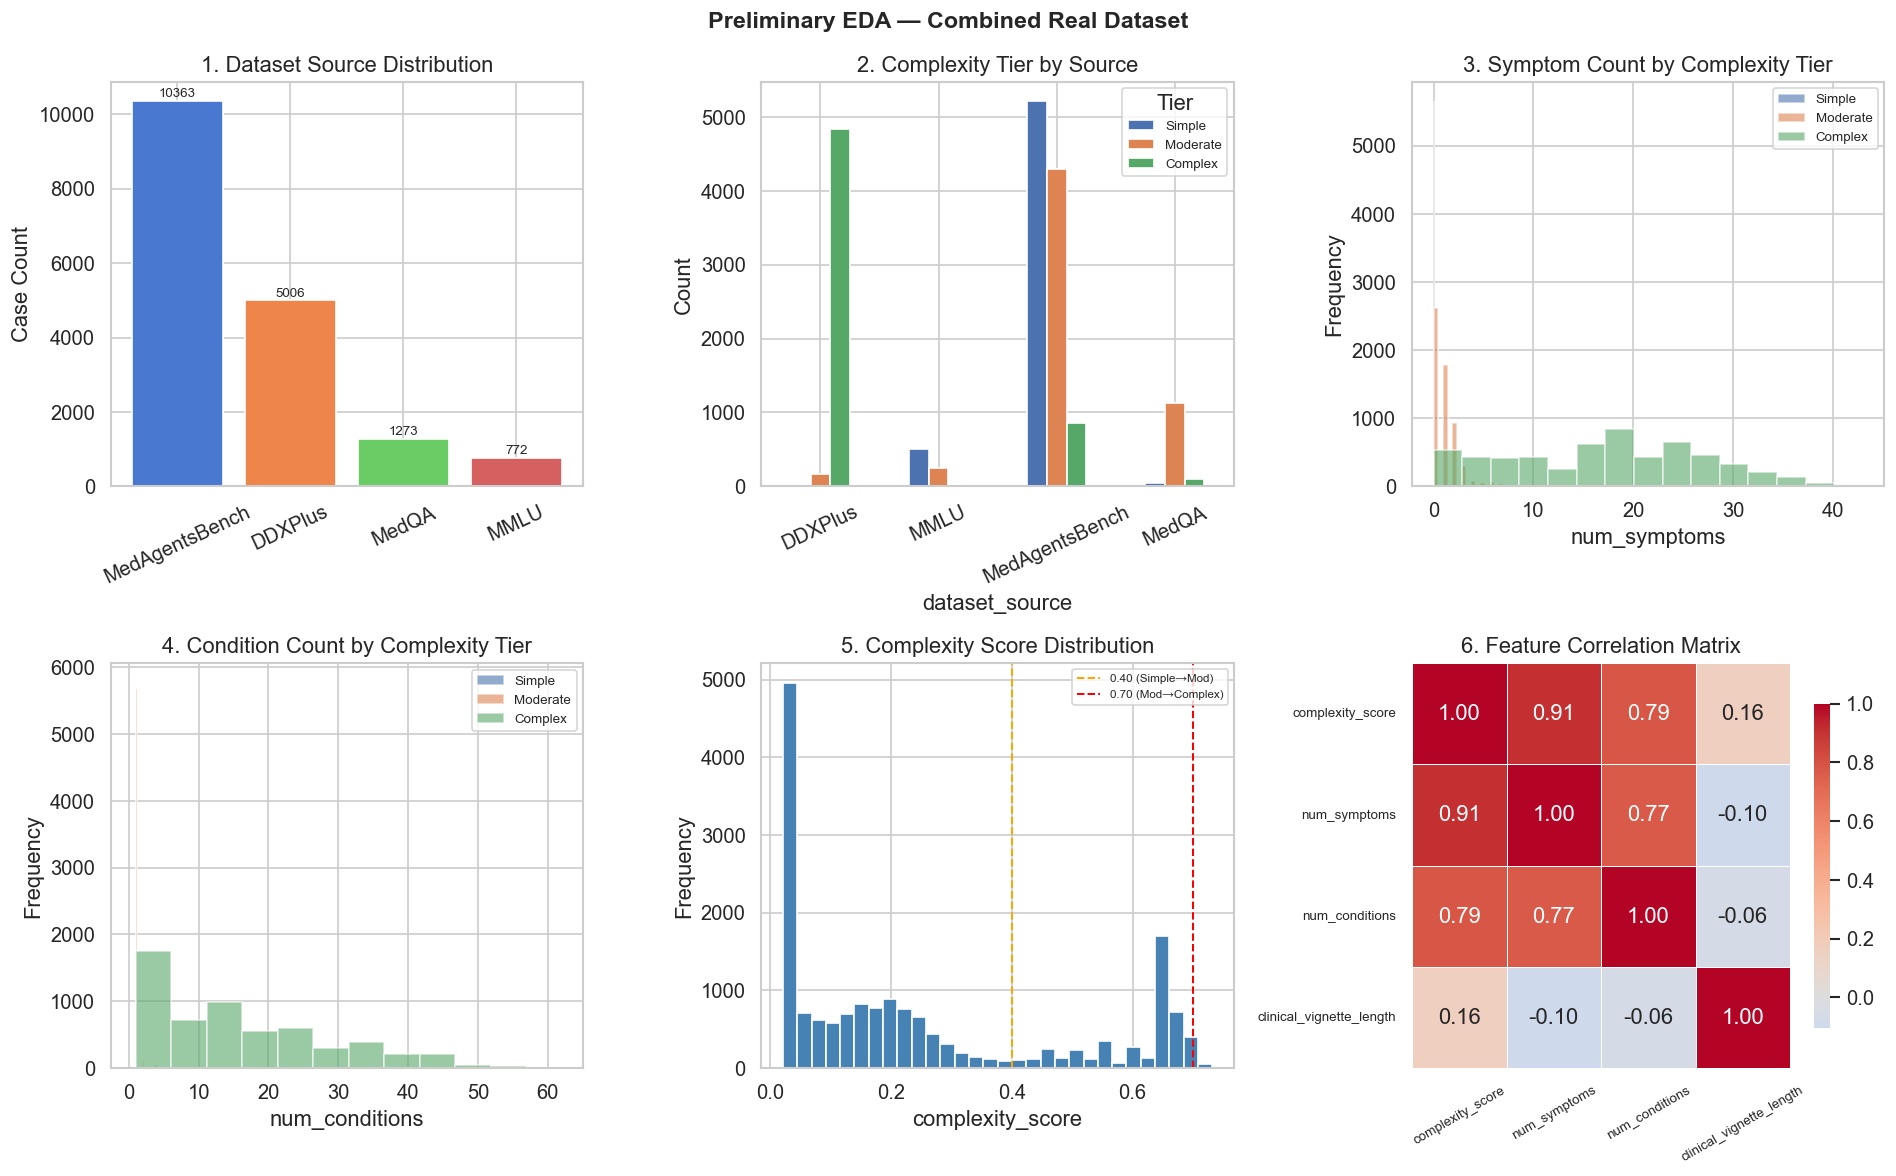


── Summary Statistics by Dataset Source ──
                n_cases  pct_simple  pct_moderate  pct_complex  mean_symptoms  mean_conditions  mean_score
dataset_source                                                                                            
DDXPlus            5006         0.0           3.3         96.7          19.70             18.4       0.585
MMLU                772        65.9          32.5          1.6           0.33              1.0       0.074
MedAgentsBench    10363        50.4          41.4          8.2           0.52              1.0       0.115
MedQA              1273         3.5          88.9          7.6           1.10              1.0       0.169

── Missing Value Audit ──
No missing values.


In [18]:
# ── §1.7: Preliminary EDA on combined_df (pre-inference case-level data) ──────
print(f"Total cases: {len(combined_df):,}")
print(f"Sources:     {combined_df['dataset_source'].nunique()}")
print(f"Columns:     {list(combined_df.columns)}")
print()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Preliminary EDA — Combined Real Dataset', fontsize=14, fontweight='bold')

# ── 1. Source distribution ────────────────────────────────────────────────────
src_counts = combined_df['dataset_source'].value_counts()
axes[0, 0].bar(src_counts.index, src_counts.values,
               color=sns.color_palette('muted', len(src_counts)), edgecolor='white')
axes[0, 0].set_title('1. Dataset Source Distribution')
axes[0, 0].set_ylabel('Case Count')
axes[0, 0].tick_params(axis='x', rotation=25)
for i, (s, cnt) in enumerate(src_counts.items()):
    axes[0, 0].text(i, cnt + max(src_counts) * 0.01, str(cnt), ha='center', fontsize=8)

# ── 2. Complexity tier by source ──────────────────────────────────────────────
tier_by_src = (combined_df.groupby(['dataset_source', 'task_complexity'])
               .size().unstack(fill_value=0))
tier_by_src = tier_by_src.reindex(columns=['Simple', 'Moderate', 'Complex'], fill_value=0)
tier_by_src.plot(kind='bar', ax=axes[0, 1],
                 color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white')
axes[0, 1].set_title('2. Complexity Tier by Source')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=25)
axes[0, 1].legend(title='Tier', fontsize=8)

# ── 3. Symptom count by complexity tier ───────────────────────────────────────
for tier, color in zip(COMPLEXITY_TIERS, ['#4C72B0', '#DD8452', '#55A868']):
    sub = combined_df[combined_df['task_complexity'] == tier]['num_symptoms']
    axes[0, 2].hist(sub, bins=15, alpha=0.6, label=tier, color=color, edgecolor='white')
axes[0, 2].set_title('3. Symptom Count by Complexity Tier')
axes[0, 2].set_xlabel('num_symptoms')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend(fontsize=8)

# ── 4. Condition count by complexity tier ─────────────────────────────────────
for tier, color in zip(COMPLEXITY_TIERS, ['#4C72B0', '#DD8452', '#55A868']):
    sub = combined_df[combined_df['task_complexity'] == tier]['num_conditions']
    axes[1, 0].hist(sub, bins=12, alpha=0.6, label=tier, color=color, edgecolor='white')
axes[1, 0].set_title('4. Condition Count by Complexity Tier')
axes[1, 0].set_xlabel('num_conditions')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend(fontsize=8)

# ── 5. Complexity score distribution ─────────────────────────────────────────
combined_df['complexity_score'].hist(bins=30, ax=axes[1, 1],
                                     color='steelblue', edgecolor='white')
axes[1, 1].set_title('5. Complexity Score Distribution')
axes[1, 1].set_xlabel('complexity_score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(0.40, color='orange', linestyle='--', linewidth=1.2, label='0.40 (Simple→Mod)')
axes[1, 1].axvline(0.70, color='red',    linestyle='--', linewidth=1.2, label='0.70 (Mod→Complex)')
axes[1, 1].legend(fontsize=7)

# ── 6. Feature correlation heatmap ────────────────────────────────────────────
num_cols = ['complexity_score', 'num_symptoms', 'num_conditions', 'clinical_vignette_length']
corr_df  = combined_df[num_cols].corr()
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1, 2], linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1, 2].set_title('6. Feature Correlation Matrix')
axes[1, 2].tick_params(axis='x', rotation=30, labelsize=8)
axes[1, 2].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_eda_overview.png', bbox_inches='tight')
plt.show()

# ── Summary statistics table ──────────────────────────────────────────────────
print("\n── Summary Statistics by Dataset Source ──")
summary_eda = (combined_df.groupby('dataset_source')
               .agg(
                   n_cases         =('question_id', 'count'),
                   pct_simple      =('task_complexity', lambda x: round((x == 'Simple').mean() * 100, 1)),
                   pct_moderate    =('task_complexity', lambda x: round((x == 'Moderate').mean() * 100, 1)),
                   pct_complex     =('task_complexity', lambda x: round((x == 'Complex').mean() * 100, 1)),
                   mean_symptoms   =('num_symptoms', lambda x: round(x.mean(), 2)),
                   mean_conditions =('num_conditions', lambda x: round(x.mean(), 2)),
                   mean_score      =('complexity_score', lambda x: round(x.mean(), 3)),
               ))
print(summary_eda.to_string())

# ── Missing value audit ────────────────────────────────────────────────────────
print("\n── Missing Value Audit ──")
miss = combined_df.isnull().sum()
miss_nonzero = miss[miss > 0]
if len(miss_nonzero) == 0:
    print("No missing values.")
else:
    print(miss_nonzero.to_string())


§1.7a  SUPPLEMENTARY EDA

── 1. Complexity Tier Balance (overall) ──
                 count   pct
task_complexity             
Moderate          5841  33.5
Complex           5802  33.3
Simple            5771  33.1

── 2. Source × Complexity Tier — Chi-squared Independence Test ──
  χ²(6) = 14370.22,  p = 0.0000
  ✗ CONFOUNDED: complexity tier distribution differs significantly across sources.
    RQ2 results should be interpreted with this source–complexity overlap in mind.

── 3. Dead / Collinear Feature Audit ──
  has_structured_labs: column absent.
step_level value counts:step_level
0    16141
2     1273
  step_level==2 ↔ MedQA overlap: 100.0% — near-perfect collinearity with dataset_source dummy.

── 4. VIF — RQ4 Numeric Feature Matrix ──
                 feature   VIF
        complexity_score 20.31
            num_symptoms 12.12
          num_conditions  3.87
clinical_vignette_length  3.38
  ⚠ VIF > 5 for: ['complexity_score', 'num_symptoms']
    complexity_score is a linear combi

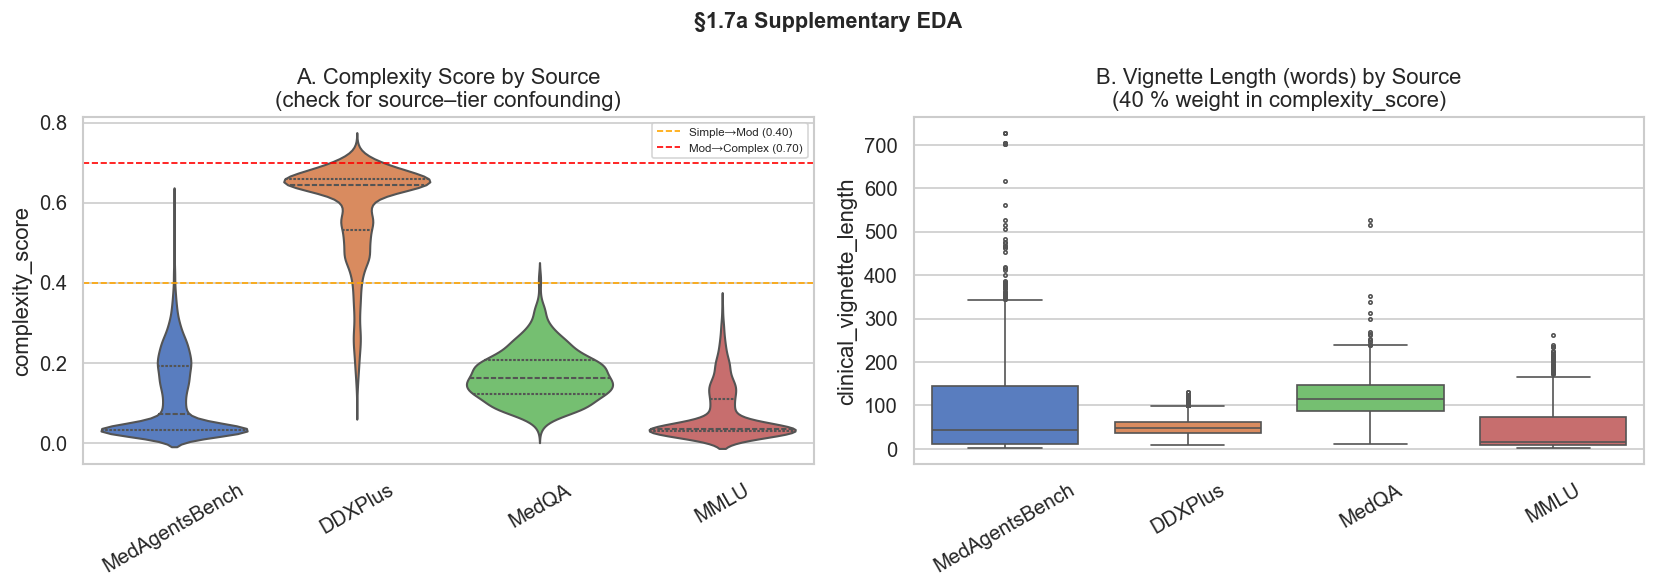


Figure saved → outputs/fig_eda_supplementary.png


In [19]:
# ── §1.7a: Supplementary EDA — Confounding, Feature Quality & Balance ─────────
# Covers five gaps identified in the primary EDA:
#   1. Source–complexity confounding (Chi-squared + violin)
#   2. Dead feature audit (has_structured_labs, step_level)
#   3. VIF check for RQ4 feature matrix multicollinearity
#   4. clinical_vignette_length distribution by source
#   5. Complexity tier balance (explicit proportions)

from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

print("=" * 65)
print("§1.7a  SUPPLEMENTARY EDA")
print("=" * 65)

# ── 1. Complexity tier class balance ─────────────────────────────────────────
print("\n── 1. Complexity Tier Balance (overall) ──")
tier_balance = combined_df['task_complexity'].value_counts(normalize=True).mul(100).round(1)
tier_counts  = combined_df['task_complexity'].value_counts()
tier_summary = pd.DataFrame({'count': tier_counts, 'pct': tier_balance})
print(tier_summary.to_string())
if tier_balance.min() < 15:
    print("  ⚠ WARNING: minority tier < 15 % — ANOVA cell counts may be low.")

# ── 2. Source–complexity confounding: Chi-squared test ───────────────────────
print("\n── 2. Source × Complexity Tier — Chi-squared Independence Test ──")
ct = pd.crosstab(combined_df['dataset_source'], combined_df['task_complexity'])
chi2, p_chi2, dof, _ = chi2_contingency(ct)
print(f"  χ²({dof}) = {chi2:.2f},  p = {p_chi2:.4f}")
if p_chi2 < 0.05:
    print("  ✗ CONFOUNDED: complexity tier distribution differs significantly across sources.")
    print("    RQ2 results should be interpreted with this source–complexity overlap in mind.")
else:
    print("  ✓ Not significantly confounded (p ≥ .05).")

# ── 3. Dead feature audit ─────────────────────────────────────────────────────
print("\n── 3. Dead / Collinear Feature Audit ──")
if 'has_structured_labs' in combined_df.columns:
    hsl = combined_df['has_structured_labs'].value_counts()
    print(f"has_structured_labs value counts:{hsl.to_string()}")
    if hsl.index.tolist() == [0] or (len(hsl) == 1):
        print("  ⚠ has_structured_labs is constant (all zeros) — zero-variance feature; "
              "drop from RQ4 classifier.")
else:
    print("  has_structured_labs: column absent.")

if 'step_level' in combined_df.columns:
    sl = combined_df['step_level'].value_counts()
    print(f"step_level value counts:{sl.to_string()}")
    medqa_flag = (combined_df['dataset_source'] == 'MedQA') if 'MedQA' in combined_df['dataset_source'].values else None
    if medqa_flag is not None:
        overlap = (combined_df['step_level'] == 2).eq(medqa_flag).mean()
        print(f"  step_level==2 ↔ MedQA overlap: {overlap:.1%} — "
              f"{'near-perfect collinearity with dataset_source dummy' if overlap > 0.95 else 'partial overlap'}.")
else:
    print("  step_level: column absent.")

# ── 4. VIF for RQ4 feature matrix ────────────────────────────────────────────
print("\n── 4. VIF — RQ4 Numeric Feature Matrix ──")
vif_cols = [c for c in ['complexity_score', 'num_symptoms', 'num_conditions',
                         'clinical_vignette_length'] if c in combined_df.columns]
vif_data = combined_df[vif_cols].fillna(0).astype(float)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    vif_vals = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_cols))]
vif_df = pd.DataFrame({'feature': vif_cols, 'VIF': [round(v, 2) for v in vif_vals]})
print(vif_df.to_string(index=False))
high_vif = vif_df[vif_df['VIF'] > 5]
if len(high_vif):
    print(f"  ⚠ VIF > 5 for: {high_vif['feature'].tolist()}")
    print("    complexity_score is a linear combination of its components — "
          "use either the score OR its raw features in the RQ4 classifier, not both.")

# ── 5. Visualisations: violin plots ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('§1.7a Supplementary EDA', fontsize=13, fontweight='bold')

# Panel A: complexity_score by source
src_order = combined_df['dataset_source'].value_counts().index.tolist()
sns.violinplot(data=combined_df, x='dataset_source', y='complexity_score',
               order=src_order, palette='muted', inner='quartile', ax=axes[0])
axes[0].axhline(0.40, color='orange', linestyle='--', linewidth=1, label='Simple→Mod (0.40)')
axes[0].axhline(0.70, color='red',    linestyle='--', linewidth=1, label='Mod→Complex (0.70)')
axes[0].set_title('A. Complexity Score by Source\n(check for source–tier confounding)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=7)

# Panel B: clinical_vignette_length by source
sns.boxplot(data=combined_df, x='dataset_source', y='clinical_vignette_length',
            order=src_order, palette='muted', fliersize=2, ax=axes[1])
axes[1].set_title('B. Vignette Length (words) by Source\n(40 % weight in complexity_score)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_eda_supplementary.png', bbox_inches='tight')
plt.show()
print("\nFigure saved → outputs/fig_eda_supplementary.png")


In [ ]:
# ── Patch 3: Use adaptive_router for routing_decision in adaptive config ──
# In real-API mode the src.agents.adaptive_router(c_score) function is used
# instead of the hard-coded routing_map dict above.
# Import is already available via the Section 0 setup cell:
#   from src.agents import adaptive_router as _router
# Usage in the live simulation loop:
#   routing_decision = _router(c_score) if cfg == 'adaptive' else CANONICAL_ROUTING[cfg]

---
## Section 2 — Complexity Feature Engineering

In [20]:
# NOTE: This local definition is superseded by the import in the next cell (§2 Patch 4).
# After that import executes, compute_complexity_features refers to the
# calibration-aware version in src/preprocessing.py (no df.max() leakage).
def compute_complexity_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive NLP-based complexity_score and associated features from the
    clinical_vignette column.  When the column is absent the function
    is a no-op (simulation data already has these fields).
    """
    if 'clinical_vignette' not in df.columns:
        return df

    df = df.copy()

    if 'clinical_vignette_length' not in df.columns:
        df['clinical_vignette_length'] = df['clinical_vignette'].str.len().fillna(0).astype(int)

    if 'num_symptoms' not in df.columns:
        # Heuristic: count comma-separated or semicolon-separated symptom mentions
        symptom_pattern = re.compile(
            r'\b(fever|pain|dyspnea|cough|fatigue|nausea|vomiting|'
            r'dizziness|headache|rash|edema|tachycardia|bradycardia|'
            r'hypotension|hypertension|confusion|weakness|bleeding)\b',
            re.IGNORECASE
        )
        df['num_symptoms'] = df['clinical_vignette'].apply(
            lambda t: len(set(symptom_pattern.findall(str(t))))
        )

    if 'num_conditions' not in df.columns:
        df['num_conditions'] = 1  # default; overridden by DDXPlus loader

    if 'complexity_score' not in df.columns:
        # Composite score: normalised average of three proxy features
        max_len  = df['clinical_vignette_length'].max() or 1
        max_symp = df['num_symptoms'].max() or 1
        max_cond = df['num_conditions'].max() or 1
        df['complexity_score'] = (
            df['clinical_vignette_length'] / max_len * 0.4
            + df['num_symptoms']           / max_symp * 0.4
            + df['num_conditions']          / max_cond * 0.2
        ).round(4)

    if 'task_complexity' not in df.columns:
        df['task_complexity'] = pd.cut(
            df['complexity_score'],
            bins=[-0.01, 0.35, 0.65, 1.01],
            labels=['Simple', 'Moderate', 'Complex']
        ).astype(str)

    return df

Tier thresholds: Simple < 0.0730 ≤ Moderate < 0.2647 ≤ Complex

Complexity tier distribution (target ~33/33/33):
  Simple  : 5,771  (33.1 %)
  Moderate: 5,841  (33.5 %)
  Complex : 5,802  (33.3 %)


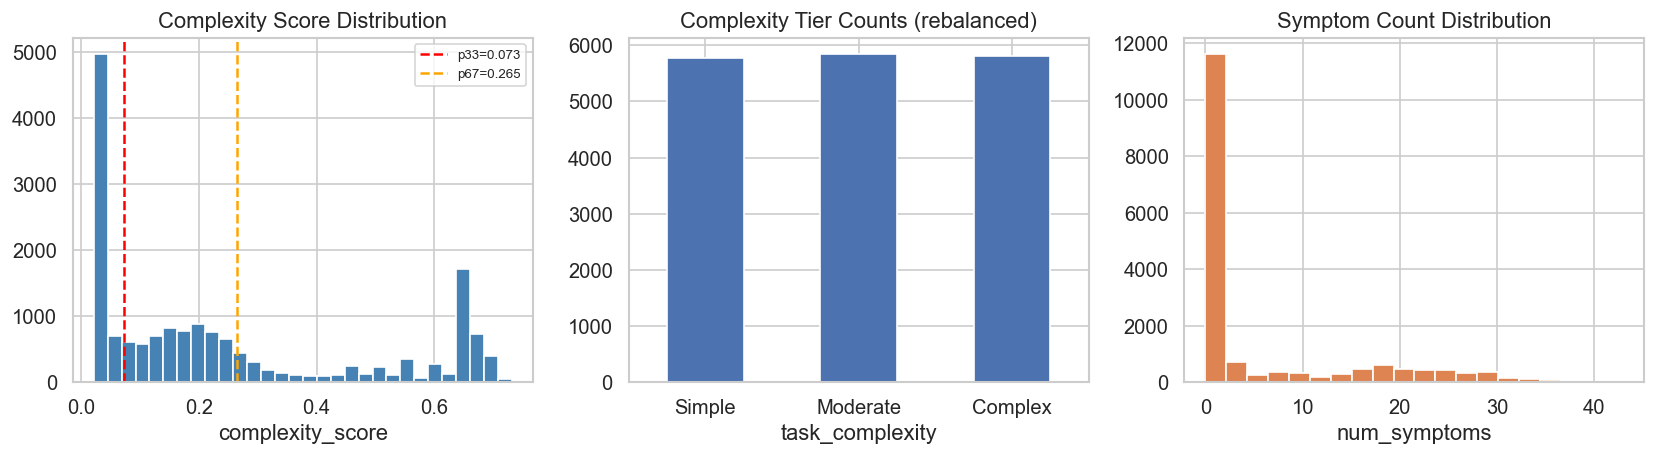

Complexity features applied to combined_df.


In [21]:
# ── §2: Complexity features + data-driven tier thresholds ───────────────────
import importlib, src.preprocessing
importlib.reload(src.preprocessing)
from src.preprocessing import (
    compute_complexity_features,
    compute_tier_thresholds,
)

combined_df = compute_complexity_features(combined_df)

# Data-driven thresholds: 33rd / 67th percentile → ~equal Simple/Moderate/Complex
p33, p67 = compute_tier_thresholds(combined_df)
print(f'Tier thresholds: Simple < {p33:.4f} ≤ Moderate < {p67:.4f} ≤ Complex')

tier_counts = combined_df['task_complexity'].value_counts()
tier_pcts   = combined_df['task_complexity'].value_counts(normalize=True).mul(100).round(1)
print('\nComplexity tier distribution (target ~33/33/33):')
for tier in ['Simple', 'Moderate', 'Complex']:
    print(f'  {tier:8s}: {tier_counts.get(tier, 0):5,}  ({tier_pcts.get(tier, 0):.1f} %)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
combined_df['complexity_score'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(p33, color='red',    linestyle='--', label=f'p33={p33:.3f}')
axes[0].axvline(p67, color='orange', linestyle='--', label=f'p67={p67:.3f}')
axes[0].set_title('Complexity Score Distribution')
axes[0].set_xlabel('complexity_score')
axes[0].legend(fontsize=8)

combined_df['task_complexity'].value_counts().reindex(['Simple','Moderate','Complex']).plot(
    kind='bar', ax=axes[1], color='#4C72B0')
axes[1].set_title('Complexity Tier Counts (rebalanced)')
axes[1].tick_params(axis='x', rotation=0)

combined_df['num_symptoms'].hist(bins=20, ax=axes[2], color='#DD8452', edgecolor='white')
axes[2].set_title('Symptom Count Distribution')
axes[2].set_xlabel('num_symptoms')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_complexity_eda.png', bbox_inches='tight')
plt.show()
print('Complexity features applied to combined_df.')


---
## Section 3 — Multi-Agent System Implementation

In [22]:
# ─── Agent roles ──────────────────────────────────────────────────────────────
AGENT_ROLES = {
    'solo':    ['Generalist'],
    'group-2': ['Internist', 'Specialist'],
    'group-3': ['Internist', 'Specialist', 'Moderator'],
    'MDT':     ['Internist', 'Specialist', 'Radiologist', 'Pharmacist', 'Moderator'],
}

SYSTEM_PROMPTS = {
    'Generalist': (
        'You are a board-certified general-practice physician. '
        'Diagnose the following case concisely. '
        'Respond with the single most likely diagnosis only.'
    ),
    'Internist': (
        'You are a board-certified internist contributing to a multi-specialist '
        'diagnostic panel. Provide your primary diagnosis and key clinical reasoning.'
    ),
    'Specialist': (
        'You are a specialist (cardiology / pulmonology / neurology as appropriate). '
        'Critically evaluate the case. State your diagnosis and any differential.'
    ),
    'Radiologist': (
        'You are a radiologist. Comment on imaging findings implied by the case '
        'and their diagnostic implications.'
    ),
    'Pharmacist': (
        'You are a clinical pharmacist. Identify any drug-disease interactions '
        'or pharmacological clues relevant to the diagnosis.'
    ),
    'Moderator': (
        'You are the diagnostic moderator. Synthesize the inputs from your '
        'colleagues and return a single final diagnosis.'
    ),
}


class TokenTracker:
    """Accumulate token usage across an inference run."""
    def __init__(self):
        self.prompt_tokens     = 0
        self.completion_tokens = 0

    def add(self, usage):
        if hasattr(usage, 'prompt_tokens'):
            self.prompt_tokens     += usage.prompt_tokens
            self.completion_tokens += usage.completion_tokens
        elif isinstance(usage, dict):
            self.prompt_tokens     += usage.get('prompt_tokens', 0)
            self.completion_tokens += usage.get('completion_tokens', 0)

    @property
    def total(self):
        return self.prompt_tokens + self.completion_tokens


def openai_call(system: str, user: str, model: str = 'gpt-4o-mini') -> Tuple[str, dict]:
    """Thin wrapper around OpenAI chat completion."""
    import openai
    client = openai.OpenAI(api_key=OPENAI_API_KEY)
    resp = client.chat.completions.create(
        model=model,
        messages=[{'role': 'system', 'content': system},
                  {'role': 'user',   'content': user}],
        max_tokens=512,
        temperature=0.0,
    )
    text  = resp.choices[0].message.content.strip()
    usage = {'prompt_tokens':     resp.usage.prompt_tokens,
             'completion_tokens': resp.usage.completion_tokens}
    return text, usage


# Map backbone display names to Anthropic model IDs
_ANTHROPIC_MODEL_MAP = {
    'claude-haiku':  'claude-haiku-4-5-20251001',
    'claude-sonnet': 'claude-sonnet-4-6',
    'claude-opus':   'claude-opus-4-7',
}

def anthropic_call(system: str, user: str, backbone: str = 'claude-sonnet') -> Tuple[str, dict]:
    """Thin wrapper around Anthropic Messages API."""
    import anthropic
    model = _ANTHROPIC_MODEL_MAP.get(backbone.lower(), 'claude-haiku-4-5-20251001')
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    resp = client.messages.create(
        model=model,
        max_tokens=512,
        temperature=0,
        system=system,
        messages=[{'role': 'user', 'content': user}],
    )
    text_blocks = [b for b in resp.content if hasattr(b, 'text')]
    if not text_blocks:
        raise RuntimeError(
            f"Anthropic API returned no text content. "
            f"stop_reason={resp.stop_reason!r}, model={model!r}"
        )
    text  = text_blocks[0].text.strip()
    usage = {'prompt_tokens':     resp.usage.input_tokens,
             'completion_tokens': resp.usage.output_tokens}
    return text, usage


def llm_call(system: str, user: str, backbone: str) -> Tuple[str, dict]:
    """Route to the correct backend."""
    backbone = backbone.lower()
    if 'claude' in backbone:
        return anthropic_call(system, user, backbone=backbone)
    elif 'llama' in backbone:
        # Local Ollama / vLLM endpoint — adapt as needed
        raise NotImplementedError('Configure Llama endpoint in llm_call()')
    else:
        model = 'gpt-4o' if 'gpt-4o' in backbone else 'gpt-4o-mini'
        return openai_call(system, user, model=model)


print('Agent scaffolding defined.')

Agent scaffolding defined.


In [23]:
def complexity_assessor(vignette: str, backbone: str) -> Tuple[str, float, dict]:
    """
    MDAgents-style complexity estimator.
    Returns (tier, score, usage): tier is Simple/Moderate/Complex,
    score is a representative float in [0,1] for that tier.
    """
    system = (
        'You are a medical triage classifier. '
        'Classify the clinical complexity of the case as exactly one of: '
        'Simple, Moderate, or Complex. '
        'Respond with ONLY that single word.'
    )
    result, usage = llm_call(system, vignette, backbone)
    tier = result.strip().capitalize()
    if tier not in COMPLEXITY_TIERS:
        tier = 'Moderate'
    # Map tier to representative score for 4-tier routing
    score = {'Simple': 0.20, 'Moderate': 0.50, 'Complex': 0.85}[tier]
    return tier, score, usage


def adaptive_router(complexity_score: float) -> str:
    """Map 0-1 complexity score to routing tier — synopsis §2 thresholds.
    <0.40 → solo, 0.40-0.60 → group-2, 0.60-0.80 → group-3, ≥0.80 → MDT
    """
    if complexity_score < 0.40:
        return 'solo'
    elif complexity_score < 0.60:
        return 'group-2'
    elif complexity_score < 0.80:
        return 'group-3'
    else:
        return 'MDT'


def run_single_agent(vignette: str, backbone: str) -> Tuple[str, int, int]:
    """Returns (answer, total_tokens, reasoning_steps)."""
    tracker = TokenTracker()
    system  = SYSTEM_PROMPTS['Generalist']
    answer, usage = llm_call(system, vignette, backbone)
    tracker.add(usage)
    return answer, tracker.total, 1


def run_static_multi_agent(vignette: str, backbone: str,
                           tier: str = 'group-3') -> Tuple[str, int, int]:
    """Static MAS: always uses the same collaboration tier."""
    tracker = TokenTracker()
    roles   = AGENT_ROLES[tier]
    opinions: List[str] = []

    for role in roles[:-1]:   # all except moderator
        sys_p  = SYSTEM_PROMPTS[role]
        ctx    = vignette
        if opinions:
            ctx += '\n\nPrior opinions:\n' + '\n'.join(f'- {o}' for o in opinions)
        opinion, usage = llm_call(sys_p, ctx, backbone)
        tracker.add(usage)
        opinions.append(f'{role}: {opinion}')

    # Moderator synthesis
    mod_ctx = vignette + '\n\nPanel inputs:\n' + '\n'.join(opinions)
    final, usage = llm_call(SYSTEM_PROMPTS['Moderator'], mod_ctx, backbone)
    tracker.add(usage)

    return final, tracker.total, len(roles)


def run_adaptive_multi_agent(vignette: str, backbone: str) -> Tuple[str, int, int, str, int]:
    """Adaptive MAS: classify complexity first, then select routing tier.
    Returns (answer, total_tokens, steps, routing_tier, routing_overhead_tokens).
    """
    routing_tracker = TokenTracker()

    # Step 1 — complexity assessment (routing overhead)
    tier, score, assess_usage = complexity_assessor(vignette, backbone)
    routing_tracker.add(assess_usage)
    routing_overhead = routing_tracker.total

    # Step 2 — score-based 4-tier routing
    routing = adaptive_router(score)

    # Step 3 — run appropriate config
    if routing == 'solo':
        answer, inf_tokens, steps = run_single_agent(vignette, backbone)
    else:
        answer, inf_tokens, steps = run_static_multi_agent(vignette, backbone, tier=routing)

    total_tokens = routing_overhead + inf_tokens
    return answer, total_tokens, steps, routing, routing_overhead


print('run_single_agent / run_static_multi_agent / run_adaptive_multi_agent defined.')

run_single_agent / run_static_multi_agent / run_adaptive_multi_agent defined.


---
## Section 4 — Inference Runs (Baseline + Adaptive)

In [25]:

# ── §4: Inference — Batch API (production) + Async (dev) ────────────────────────────────────
import anthropic as _anthropic_sdk
import asyncio, time
from copy import deepcopy
from pathlib import Path
from tqdm.auto import tqdm

import importlib
import src.agents as _agents_mod
importlib.reload(_agents_mod)

from src.evaluator    import answer_is_correct as _eval_answer_is_correct
from src.agents       import (adaptive_router, build_batch_request,
                               run_single_agent, run_static_multi_agent,
                               run_single_agent_async, run_static_multi_agent_async,
                               safe_acc_per_1k, SYSTEM_PROMPTS)
from src.llm_client   import LLMClient, AsyncLLMClient, BACKBONE_MODEL_MAP

BATCH_CHECKPOINT_DIR = OUTPUT_DIR / 'batch_checkpoints'
BATCH_CHECKPOINT_DIR.mkdir(exist_ok=True)

# ─── Helpers ─────────────────────────────────────────────────────────────────────────────

def _submit_and_wait(requests, round_name, client_anth):
    """Submit a batch round, poll until done, return {custom_id: {text, usage}}.
    Loads from checkpoint if one exists -- skips re-submission on restart.
    """
    ckpt = BATCH_CHECKPOINT_DIR / f'{round_name}.json'
    if ckpt.exists():
        print(f'  [{round_name}] Loaded from checkpoint.')
        return json.loads(ckpt.read_text())

    batch = client_anth.messages.batches.create(requests=requests)
    print(f'  [{round_name}] Submitted {len(requests):,} requests -- batch_id={batch.id}')

    while True:
        batch = client_anth.messages.batches.retrieve(batch.id)
        if batch.processing_status == 'ended':
            break
        print(f'  [{round_name}] {batch.request_counts.processing} remaining...', end='\r')
        time.sleep(30)

    results = {}
    for result in client_anth.messages.batches.results(batch.id):
        if result.result.type == 'succeeded':
            msg  = result.result.message
            text = next((b.text for b in msg.content if b.type == 'text'), '')
            results[result.custom_id] = {
                'text': text,
                'usage': {'prompt_tokens':     msg.usage.input_tokens,
                          'completion_tokens': msg.usage.output_tokens},
            }
        else:
            results[result.custom_id] = {
                'text': '',
                'usage': {'prompt_tokens': 0, 'completion_tokens': 0},
            }

    ckpt.write_text(json.dumps(results))
    print(f'  [{round_name}] Complete -- {len(results):,} results saved.')
    return results


def _tok(res):
    u = res.get('usage', {})
    return u.get('prompt_tokens', 0) + u.get('completion_tokens', 0)


def _assemble_records(rows, r1, r2, r3, routing, mdt_sync, backbone):
    """Merge three batch rounds into results_df rows (same schema as old run_inference)."""
    canonical = {'single-agent': 'solo', 'static_multi-agent': 'group-3'}
    records = []
    for row in rows:
        qid      = row['question_id']
        gt       = str(row['correct_answer'])
        tier     = routing[qid]
        src_key  = row.get('dataset_source')

        base = {k: row.get(k) for k in [
            'question_id', 'dataset_source', 'task_complexity',
            'num_symptoms', 'num_conditions', 'complexity_score',
            'clinical_vignette_length']}
        base['llm_backbone'] = backbone

        sa_res  = r1.get(f'{qid}__sa',        {'text': '', 'usage': {}})
        int_res = r1.get(f'{qid}__internist', {'text': '', 'usage': {}})
        spe_res = r2.get(f'{qid}__specialist',{'text': '', 'usage': {}})
        mod_res = r3.get(f'{qid}__moderator', {'text': '', 'usage': {}})

        sa_ans  = sa_res['text']
        sma_ans = mod_res['text']
        sa_tok  = _tok(sa_res)
        sma_tok = _tok(int_res) + _tok(spe_res) + _tok(mod_res)

        if tier == 'MDT' and qid in mdt_sync:
            ada_ans, ada_tok, ada_steps = (
                mdt_sync[qid]['text'], mdt_sync[qid]['tokens'], mdt_sync[qid]['steps'])
        elif tier == 'solo':
            ada_ans, ada_tok, ada_steps = sa_ans, sa_tok, 1
        elif tier == 'group-2':
            ada_ans  = spe_res['text']
            ada_tok  = _tok(int_res) + _tok(spe_res)
            ada_steps = 2
        else:  # group-3
            ada_ans, ada_tok, ada_steps = sma_ans, sma_tok, 3

        for cfg, ans, tok, steps, rd in [
            ('single-agent',       sa_ans,  sa_tok,  1,         canonical['single-agent']),
            ('static_multi-agent', sma_ans, sma_tok, 3,         canonical['static_multi-agent']),
            ('adaptive',           ada_ans, ada_tok, ada_steps, tier),
        ]:
            rec = deepcopy(base)
            rec.update({
                'agent_config':             cfg,
                'predicted_answer':         ans,
                'is_correct':              _eval_answer_is_correct(ans, gt, dataset_source=src_key),
                'token_cost':              tok,
                'latency_ms':             0.0,
                'reasoning_steps':         steps,
                'routing_decision':        rd,
                'routing_overhead_tokens': 0,
                'inference_tokens':        tok,
            })
            records.append(rec)
    return records


# ─── run_inference_batch ────────────────────────────────────────────────────────────

def run_inference_batch(df, backbone='Claude-Haiku'):
    """
    3-round Anthropic Batch API inference (50% cheaper than standard API).
    Checkpoints each round to outputs/batch_checkpoints/ -- safe to restart.

    Round 1: single-agent (Generalist) + static Internist calls (all rows)
    Round 2: static Specialist calls (sees Internist opinion from R1)
    Round 3: static Moderator calls (sees Internist+Specialist from R1+R2)
    MDT: synchronous fallback for rows with complexity_score >= 0.80
    Adaptive routing reuses batch results -- no extra calls.
    """
    client_anth = _anthropic_sdk.Anthropic(api_key=os.getenv('ANTHROPIC_API_KEY', ''))
    model_id    = BACKBONE_MODEL_MAP.get(backbone, backbone)

    rows    = [row for _, row in df.iterrows()]
    routing = {row['question_id']: adaptive_router(float(row['complexity_score']))
               for row in rows}

    # Round 1
    r1_reqs = []
    for row in rows:
        qid = row['question_id']; v = str(row['clinical_vignette'])
        r1_reqs.append(build_batch_request(f'{qid}__sa',       SYSTEM_PROMPTS['Generalist'], v, model_id))
        r1_reqs.append(build_batch_request(f'{qid}__internist', SYSTEM_PROMPTS['Internist'],  v, model_id))
    print(f'Round 1: {len(r1_reqs):,} requests')
    r1 = _submit_and_wait(r1_reqs, 'round1', client_anth)

    # Round 2
    r2_reqs = []
    for row in rows:
        qid = row['question_id']; v = str(row['clinical_vignette'])
        int_op = r1.get(f'{qid}__internist', {}).get('text', '')
        ctx    = v + '\n\nPrior opinions:\n- Internist: ' + int_op
        r2_reqs.append(build_batch_request(f'{qid}__specialist', SYSTEM_PROMPTS['Specialist'], ctx, model_id))
    print(f'Round 2: {len(r2_reqs):,} requests')
    r2 = _submit_and_wait(r2_reqs, 'round2', client_anth)

    # Round 3
    r3_reqs = []
    for row in rows:
        qid = row['question_id']; v = str(row['clinical_vignette'])
        int_op = r1.get(f'{qid}__internist',  {}).get('text', '')
        spe_op = r2.get(f'{qid}__specialist', {}).get('text', '')
        ctx    = (v + '\n\nPanel inputs:\n'
                  + f'- Internist: {int_op}\n- Specialist: {spe_op}')
        r3_reqs.append(build_batch_request(f'{qid}__moderator', SYSTEM_PROMPTS['Moderator'], ctx, model_id))
    print(f'Round 3: {len(r3_reqs):,} requests')
    r3 = _submit_and_wait(r3_reqs, 'round3', client_anth)

    # MDT synchronous fallback
    mdt_rows = [row for row in rows if routing[row['question_id']] == 'MDT']
    mdt_sync = {}
    if mdt_rows:
        print(f'Running {len(mdt_rows)} MDT cases synchronously...')
        sc = LLMClient(backbone=backbone)
        for row in mdt_rows:
            ans, tok, steps = run_static_multi_agent(str(row['clinical_vignette']), sc, tier='MDT')
            mdt_sync[row['question_id']] = {'text': ans, 'tokens': tok, 'steps': steps}

    records = _assemble_records(rows, r1, r2, r3, routing, mdt_sync, backbone)
    out = pd.DataFrame(records)
    out['acc_per_1k_tokens'] = out.apply(
        lambda r: safe_acc_per_1k(r['is_correct'], r['token_cost']), axis=1)
    return out


# ─── run_inference_async (dev path) ──────────────────────────────────────────────

async def _process_row_async(row, backbone, semaphore):
    async with semaphore:
        client   = AsyncLLMClient(backbone=backbone)
        vignette = str(row['clinical_vignette'])
        gt       = str(row['correct_answer'])
        precomp  = row.get('complexity_score')
        tier     = adaptive_router(float(precomp)) if precomp is not None else 'solo'
        base     = {k: row.get(k) for k in ['question_id', 'dataset_source', 'task_complexity',
                                              'num_symptoms', 'num_conditions', 'complexity_score',
                                              'clinical_vignette_length']}
        base['llm_backbone'] = backbone

        sa_ans, sa_tok, sa_steps   = await run_single_agent_async(vignette, client)
        sma_ans, sma_tok, sma_steps = await run_static_multi_agent_async(vignette, client)

        if tier == 'solo':
            ada_ans, ada_tok, ada_steps = sa_ans, sa_tok, 1
        elif tier == 'group-2':
            ada_ans, ada_tok, ada_steps = await run_static_multi_agent_async(vignette, client, tier='group-2')
        else:
            ada_ans, ada_tok, ada_steps = sma_ans, sma_tok, sma_steps

        canonical = {'single-agent': 'solo', 'static_multi-agent': 'group-3'}
        src_key = row.get('dataset_source')
        records = []
        for cfg, ans, tok, steps, rd in [
            ('single-agent',       sa_ans,  sa_tok,  sa_steps,  canonical['single-agent']),
            ('static_multi-agent', sma_ans, sma_tok, sma_steps, canonical['static_multi-agent']),
            ('adaptive',           ada_ans, ada_tok, ada_steps, tier),
        ]:
            rec = deepcopy(base)
            rec.update({
                'agent_config':             cfg,
                'predicted_answer':         ans,
                'is_correct':              _eval_answer_is_correct(ans, str(row['correct_answer']), dataset_source=src_key),
                'token_cost':              tok,
                'latency_ms':             0.0,
                'reasoning_steps':         steps,
                'routing_decision':        rd,
                'routing_overhead_tokens': 0,
                'inference_tokens':        tok,
            })
            records.append(rec)
        return records


async def _run_async_inner(df, backbone, max_concurrent):
    semaphore = asyncio.Semaphore(max_concurrent)
    tasks = [_process_row_async(row, backbone, semaphore) for _, row in df.iterrows()]
    all_records = []
    for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc=f'Async [{backbone}]'):
        records = await coro
        all_records.extend(records)
    return all_records


def run_inference_async(df, backbone='Claude-Haiku', max_concurrent=10):
    """Dev-mode: all 3 configs run concurrently per row. Faster iteration, full API price."""
    import threading
    _result = {}
    def _run():
        _result['records'] = asyncio.run(_run_async_inner(df, backbone, max_concurrent))
    try:
        asyncio.get_running_loop()           # raises if no loop running
        t = threading.Thread(target=_run)
        t.start(); t.join()
    except RuntimeError:
        _run()
    all_records = _result['records']
    out = pd.DataFrame(all_records)
    out['acc_per_1k_tokens'] = out.apply(
        lambda r: safe_acc_per_1k(r['is_correct'], r['token_cost']), axis=1)
    return out


# ─── Build equal-tier 1000-row inference sample ───────────────────────────────────────────
from src.preprocessing import compute_complexity_features, compute_tier_thresholds

if 'task_complexity' not in combined_df.columns:
    combined_df = compute_complexity_features(combined_df)

n_per_tier = INFERENCE_SAMPLE // 3  # 333
_frames = []
for _tier, _grp in combined_df.groupby('task_complexity'):
    _n = n_per_tier + (1 if _tier == 'Simple' else 0)  # 334+333+333 = 1000
    assert len(_grp) >= _n, f'Not enough {_tier} rows ({len(_grp)} < {_n}) -- re-run cell 29'
    _frames.append(_grp.sample(n=_n, random_state=SEED))

_strat = pd.concat(_frames).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f'Inference sample: {len(_strat):,} rows')
print('Tier breakdown:', dict(_strat['task_complexity'].value_counts()))
print('Source breakdown:', dict(_strat['dataset_source'].value_counts()))

# ─── Run inference ─────────────────────────────────────────────────────────────────────────────
# Production:   results_df = run_inference_batch(_strat, backbone='Claude-Haiku')
results_df = run_inference_async(_strat, backbone='Claude-Haiku', max_concurrent=10)
#results_df = run_inference_batch(_strat, backbone='Claude-Haiku')

print(f'\nInference complete: {len(results_df):,} rows')
results_df.groupby('agent_config')['is_correct'].mean().rename('accuracy').round(4)


Inference sample: 1,000 rows
Tier breakdown: {'Simple': 334, 'Moderate': 333, 'Complex': 333}
Source breakdown: {'MedAgentsBench': 589, 'DDXPlus': 289, 'MedQA': 82, 'MMLU': 40}


Async [Claude-Haiku]: 100%|██████████| 1000/1000 [35:17<00:00,  2.12s/it]


Inference complete: 3,000 rows


agent_config
adaptive              0.503
single-agent          0.500
static_multi-agent    0.504
Name: accuracy, dtype: float64

---
## Section 5 — Statistical Analysis: RQ1 & RQ3

### 5.1 RQ1 — One-way ANOVA + Tukey HSD + Cohen's f

In [26]:
# ── Accuracy by agent configuration ──────────────────────────────────────────
groups = [
    results_df[results_df['agent_config'] == cfg]['is_correct'].values
    for cfg in AGENT_CONFIGS
]

# Levene's test for homogeneity of variance
levene_stat, levene_p = levene(*groups)
print(f'Levene test: W = {levene_stat:.4f}, p = {levene_p:.4f}')
if levene_p > 0.05:
    print('  Variance assumption: met (p > .05)')
else:
    print('  Variance assumption: VIOLATED — running Welch ANOVA via pingouin')
    welch_aov = pg.welch_anova(data=results_df, dv='is_correct', between='agent_config')
    print(welch_aov[['Source', 'ddof1', 'ddof2', 'F', 'p_unc', 'np2']].to_string(index=False))

# One-way ANOVA
f_stat, p_val = f_oneway(*groups)
print(f'\nOne-way ANOVA: F = {f_stat:.4f}, p = {p_val:.4e}')

# Cohen's f effect size
grand_mean = np.concatenate(groups).mean()
n_per_group = np.array([len(g) for g in groups])
group_means = np.array([g.mean() for g in groups])
SS_between  = sum(n * (m - grand_mean)**2 for n, m in zip(n_per_group, group_means))
SS_within   = sum(sum((x - m)**2 for x in g) for g, m in zip(groups, group_means))
N           = sum(n_per_group)
eta_sq      = SS_between / (SS_between + SS_within)
cohens_f    = np.sqrt(eta_sq / (1 - eta_sq))

print(f'η²          = {eta_sq:.4f}')
print(f"Cohen's f   = {cohens_f:.4f}  ({'large' if cohens_f >= 0.4 else 'medium' if cohens_f >= 0.25 else 'small'})")

Levene test: W = 0.0260, p = 0.9744
  Variance assumption: met (p > .05)

One-way ANOVA: F = 0.0173, p = 9.8283e-01
η²          = 0.0000
Cohen's f   = 0.0034  (small)


         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1          group2       meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------
    adaptive       single-agent   -0.003 0.9901 -0.0555 0.0495  False
    adaptive static_multi-agent    0.001 0.9989 -0.0515 0.0535  False
single-agent static_multi-agent    0.004 0.9825 -0.0485 0.0565  False
---------------------------------------------------------------------


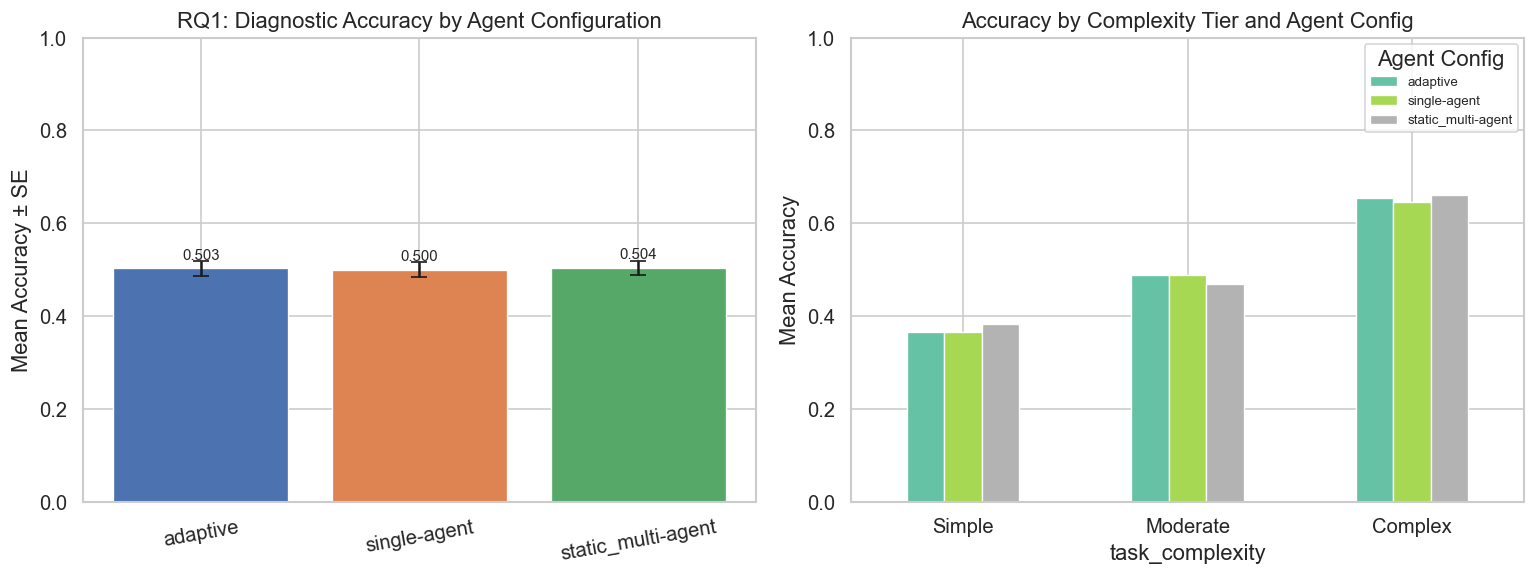

In [27]:
# Tukey HSD post-hoc
acc_long  = results_df[['agent_config', 'is_correct']].copy()
tukey_res = pairwise_tukeyhsd(acc_long['is_correct'], acc_long['agent_config'], alpha=0.05)
print(tukey_res)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

acc_means = results_df.groupby('agent_config')['is_correct'].mean()
acc_se    = results_df.groupby('agent_config')['is_correct'].sem()
ax = axes[0]
bars = ax.bar(acc_means.index, acc_means.values, yerr=acc_se.values,
              capsize=5, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white', linewidth=0.8)
ax.set_ylim(0, 1)
ax.set_ylabel('Mean Accuracy ± SE')
ax.set_title('RQ1: Diagnostic Accuracy by Agent Configuration')
ax.tick_params(axis='x', rotation=10)
for bar, mean in zip(bars, acc_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.02, f'{mean:.3f}',
            ha='center', fontsize=9)

# Accuracy by complexity × config
pivot = results_df.pivot_table(
    index='task_complexity', columns='agent_config', values='is_correct', aggfunc='mean'
).reindex(COMPLEXITY_TIERS)
pivot.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white', linewidth=0.8)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Mean Accuracy')
axes[1].set_title('Accuracy by Complexity Tier and Agent Config')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Agent Config', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_rq1_anova.png', bbox_inches='tight')
plt.show()

In [28]:
# ── RQ1: H₀ / Hₐ Decision ──────────────────────────────────────────────────
# H₀: μ_adaptive = μ_single = μ_static  (no significant accuracy difference)
# Hₐ: At least one configuration differs significantly
print("=== RQ1 Hypothesis Decision ===")
if p_val < 0.05:
    print(f"REJECT H₀  (F = {f_stat:.4f}, p = {p_val:.4e})")
    print(f"Cohen's f = {cohens_f:.4f} — effect size: {'large' if cohens_f >= 0.4 else 'medium' if cohens_f >= 0.25 else 'small'}")
    print("Conclusion: Adaptive routing produces significantly different diagnostic accuracy.")
else:
    print(f"FAIL TO REJECT H₀  (F = {f_stat:.4f}, p = {p_val:.4e})")
    print("Conclusion: No significant accuracy difference between configurations.")


=== RQ1 Hypothesis Decision ===
FAIL TO REJECT H₀  (F = 0.0173, p = 9.8283e-01)
Conclusion: No significant accuracy difference between configurations.


### 5.2 RQ3 — Accuracy-per-Token Efficiency

In [29]:
# Paired comparison: adaptive vs static multi-agent (same question_id)
adaptive_rows = results_df[results_df['agent_config'] == 'adaptive'][['question_id', 'acc_per_1k_tokens']]
static_rows   = results_df[results_df['agent_config'] == 'static_multi-agent'][['question_id', 'acc_per_1k_tokens']]

paired = adaptive_rows.merge(static_rows, on='question_id', suffixes=('_ada', '_sta'))
print(f'Paired samples: {len(paired):,}')

w_stat, w_p = wilcoxon(paired['acc_per_1k_tokens_ada'],
                        paired['acc_per_1k_tokens_sta'],
                        alternative='greater')
print(f'\nWilcoxon signed-rank (adaptive > static):  W = {w_stat:.2f}, p = {w_p:.4e}')

# Mann-Whitney U (unpaired)
u_stat, u_p = mannwhitneyu(
    results_df[results_df['agent_config'] == 'adaptive']['acc_per_1k_tokens'],
    results_df[results_df['agent_config'] == 'static_multi-agent']['acc_per_1k_tokens'],
    alternative='greater'
)
print(f'Mann-Whitney U (unpaired):                 U = {u_stat:.2f}, p = {u_p:.4e}')

# Token cost + efficiency summary table
summary = results_df.groupby('agent_config').agg(
    mean_tokens   = ('token_cost',        'mean'),
    mean_accuracy = ('is_correct',         'mean'),
    mean_eff      = ('acc_per_1k_tokens',  'mean'),
).round(4)
print('\n', summary)

Paired samples: 1,016

Wilcoxon signed-rank (adaptive > static):  W = 92626.00, p = 1.1024e-60
Mann-Whitney U (unpaired):                 U = 573385.00, p = 6.5459e-10

                     mean_tokens  mean_accuracy  mean_eff
agent_config                                            
adaptive               1321.164          0.503    1.0049
single-agent            480.814          0.500    1.2816
static_multi-agent     3489.426          0.504    0.1474


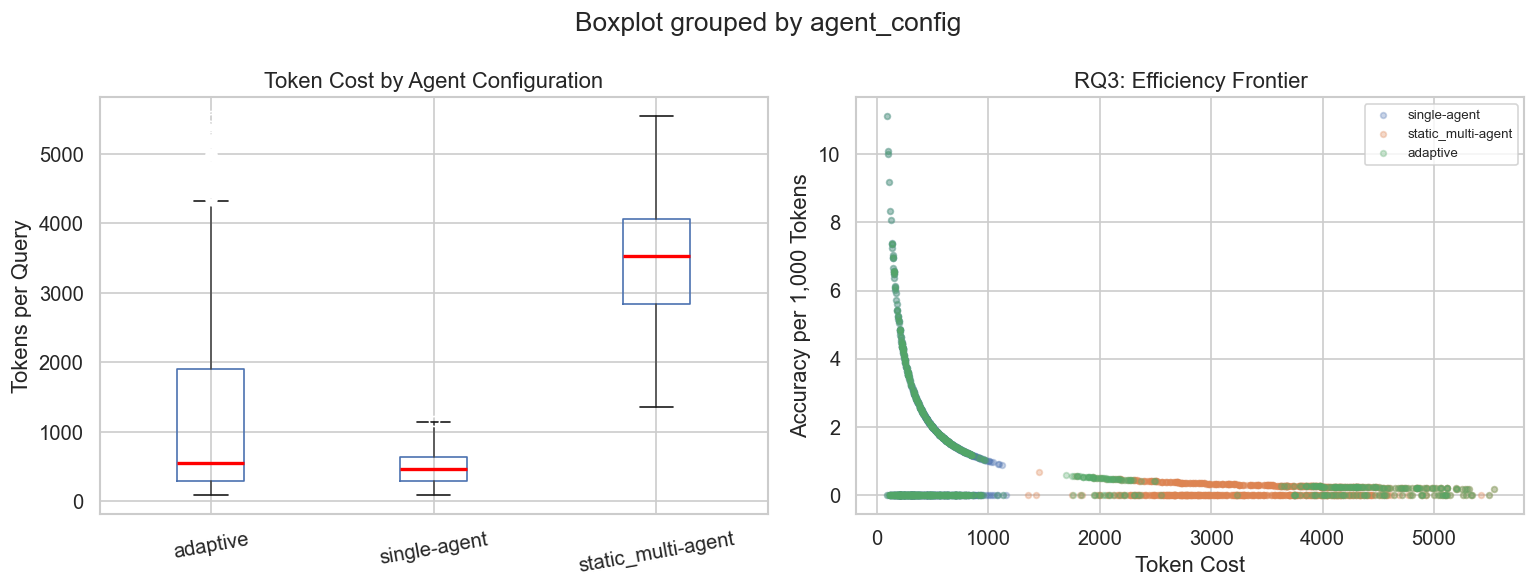

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Token cost boxplot
results_df.boxplot(
    column='token_cost', by='agent_config',
    ax=axes[0], boxprops=dict(color='#4C72B0'),
    medianprops=dict(color='red', linewidth=2)
)
axes[0].set_title('Token Cost by Agent Configuration')
axes[0].set_xlabel('')
axes[0].set_ylabel('Tokens per Query')
plt.sca(axes[0])
plt.xticks(rotation=10)

# Efficiency scatter: token cost vs accuracy per 1k tokens
palette = {'single-agent': '#4C72B0', 'static_multi-agent': '#DD8452', 'adaptive': '#55A868'}
for cfg, color in palette.items():
    sub = results_df[results_df['agent_config'] == cfg]
    axes[1].scatter(sub['token_cost'], sub['acc_per_1k_tokens'],
                    alpha=0.3, s=12, color=color, label=cfg)
axes[1].set_xlabel('Token Cost')
axes[1].set_ylabel('Accuracy per 1,000 Tokens')
axes[1].set_title('RQ3: Efficiency Frontier')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_rq3_efficiency.png', bbox_inches='tight')
plt.show()

In [31]:
# ── RQ3: H₀ / Hₐ Decision ──────────────────────────────────────────────────
# H₀: μ_adaptive_eff = μ_static_eff  (no accuracy-per-token difference)
# Hₐ: Adaptive routing achieves significantly higher accuracy-per-token efficiency
print("=== RQ3 Hypothesis Decision ===")
if w_p < 0.05:
    print(f"REJECT H₀ (Wilcoxon W = {w_stat:.2f}, p = {w_p:.4e})")
    print("Conclusion: Adaptive routing achieves significantly higher accuracy-per-token efficiency.")
else:
    print(f"FAIL TO REJECT H₀ (Wilcoxon W = {w_stat:.2f}, p = {w_p:.4e})")
    print("Conclusion: No significant efficiency advantage for adaptive routing.")
if u_p < 0.05:
    print(f"Mann-Whitney U: REJECT H₀ (U = {u_stat:.2f}, p = {u_p:.4e}) — unpaired confirmation")
else:
    print(f"Mann-Whitney U: FAIL TO REJECT H₀ (U = {u_stat:.2f}, p = {u_p:.4e})")


=== RQ3 Hypothesis Decision ===
REJECT H₀ (Wilcoxon W = 92626.00, p = 1.1024e-60)
Conclusion: Adaptive routing achieves significantly higher accuracy-per-token efficiency.
Mann-Whitney U: REJECT H₀ (U = 573385.00, p = 6.5459e-10) — unpaired confirmation


---
## Section 6 — Statistical Analysis: RQ2 (Two-way ANOVA)

In [32]:
# ── Patch 7: Cell-balance check before two-way ANOVA ──
cell_counts = results_df.groupby(['task_complexity', 'agent_config']).size().unstack()
print("Cell counts (task_complexity x agent_config):")
print(cell_counts)
min_cell = cell_counts.min().min()
if min_cell < 10:
    print(f"WARNING: minimum cell count = {min_cell}. ANOVA results may be unreliable.")
else:
    print(f"Cell balance OK (min cell n = {min_cell}).")

Cell counts (task_complexity x agent_config):
agent_config     adaptive  single-agent  static_multi-agent
task_complexity                                            
Complex               333           333                 333
Moderate              333           333                 333
Simple                334           334                 334
Cell balance OK (min cell n = 333).


In [33]:
# Two-way ANOVA: complexity_tier × agent_config → accuracy
# Using pingouin for partial η²

aov = pg.anova(
    data=results_df,
    dv='is_correct',
    between=['task_complexity', 'agent_config'],
    ss_type=2,
    detailed=True
)
print('Two-way ANOVA (Type II SS):')
print(aov[['Source', 'SS', 'DF', 'F', 'p_unc', 'np2']].to_string(index=False))

Two-way ANOVA (Type II SS):
                        Source         SS     DF         F        p_unc      np2
               task_complexity  40.483843    2.0 85.357797 8.889893e-37 0.053995
                  agent_config   0.008667    2.0  0.018273 9.818929e-01 0.000012
task_complexity * agent_config   0.199326    4.0  0.210133 9.329104e-01 0.000281
                      Residual 709.291831 2991.0       NaN          NaN      NaN


In [34]:
# ── RQ2: H₀ / Hₐ Decision ──────────────────────────────────────────────────
# H₀: Interaction β = 0 (complexity does not moderate adaptive advantage)
# Hₐ: Interaction β ≠ 0 (complexity significantly moderates the advantage)
print("=== RQ2 Hypothesis Decision ===")
try:
    interaction_row = aov[aov['Source'].str.contains('\\*', regex=True) | aov['Source'].str.contains('Interaction', case=False)]
    if len(interaction_row) == 0:
        # pingouin two-way ANOVA uses "task_complexity * agent_config" source name
        interaction_row = aov[aov['Source'].str.contains('task_complexity', case=False) & aov['Source'].str.contains('agent_config', case=False)]
    if len(interaction_row) > 0:
        int_p   = interaction_row['p_unc'].values[0]
        int_np2 = interaction_row['np2'].values[0]
        if int_p < 0.05:
            print(f"REJECT H₀  (interaction p = {int_p:.4e}, partial η² = {int_np2:.4f})")
            print("Conclusion: Task complexity significantly moderates the adaptive advantage.")
        else:
            print(f"FAIL TO REJECT H₀  (interaction p = {int_p:.4e}, partial η² = {int_np2:.4f})")
            print("Conclusion: Task complexity does not significantly moderate the advantage.")
    else:
        print("Interaction term not found — ANOVA source names:")
        print(aov[['Source', 'p_unc', 'np2']].to_string(index=False))
except Exception as e:
    print(f"Decision cell error: {e}")


=== RQ2 Hypothesis Decision ===
FAIL TO REJECT H₀  (interaction p = 9.3291e-01, partial η² = 0.0003)
Conclusion: Task complexity does not significantly moderate the advantage.



Accuracy gap (adaptive − single-agent) by complexity tier:
    tier  ada_acc   sa_acc      gap  n_ada  n_sa
  Simple 0.365269 0.365269 0.000000    334   334
Moderate 0.489489 0.489489 0.000000    333   333
 Complex 0.654655 0.645646 0.009009    333   333


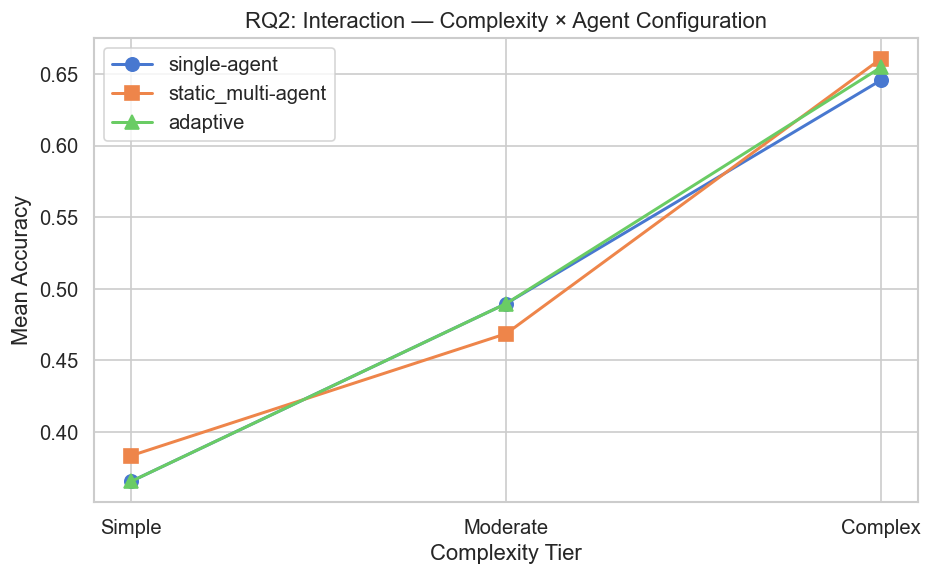

In [35]:
# Simple effects: accuracy gap (adaptive - single) within each complexity tier
gap_rows = []
for tier in COMPLEXITY_TIERS:
    ada = results_df[(results_df['agent_config'] == 'adaptive') &
                     (results_df['task_complexity'] == tier)]['is_correct']
    sa  = results_df[(results_df['agent_config'] == 'single-agent') &
                     (results_df['task_complexity'] == tier)]['is_correct']
    gap_rows.append({
        'tier':       tier,
        'ada_acc':    ada.mean(),
        'sa_acc':     sa.mean(),
        'gap':        ada.mean() - sa.mean(),
        'n_ada':      len(ada),
        'n_sa':       len(sa),
    })

gap_df = pd.DataFrame(gap_rows)
print('\nAccuracy gap (adaptive − single-agent) by complexity tier:')
print(gap_df.to_string(index=False))

# Interaction plot
fig, ax = plt.subplots(figsize=(8, 5))
for cfg, ls in zip(AGENT_CONFIGS, ['-o', '-s', '-^']):
    vals = (
        results_df[results_df['agent_config'] == cfg]
        .groupby('task_complexity')['is_correct']
        .mean()
        .reindex(COMPLEXITY_TIERS)
    )
    ax.plot(COMPLEXITY_TIERS, vals.values, ls, label=cfg, linewidth=1.8, markersize=8)
ax.set_xlabel('Complexity Tier')
ax.set_ylabel('Mean Accuracy')
ax.set_title('RQ2: Interaction — Complexity × Agent Configuration')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_rq2_interaction.png', bbox_inches='tight')
plt.show()

In [39]:
# ── Patch 12: ANCOVA with llm_backbone covariate + backbone summary ──
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Backbone summary table
backbone_summary = (
    results_df.groupby(['llm_backbone', 'agent_config'])['is_correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'accuracy', 'count': 'n'})
    .reset_index()
)
print('Backbone x Config accuracy summary:')
print(backbone_summary.to_string(index=False))

# ANCOVA: is_correct ~ task_complexity * agent_config + llm_backbone
# Build formula dynamically — only include factors with >1 unique level
ancova_df = results_df[['is_correct', 'task_complexity', 'agent_config', 'llm_backbone']].copy()
_levels = {col: ancova_df[col].nunique() for col in ['task_complexity', 'agent_config', 'llm_backbone']}
print(f'\nFactor levels: {_levels}')

try:
    _between = [c for c in ['task_complexity', 'agent_config'] if _levels[c] > 1]
    if len(_between) < 2:
        raise ValueError(f'Need >=2 between factors with variation; found {_between}')
    _main = ' * '.join(f'C({b})' for b in _between)
    _covar = [c for c in ['llm_backbone'] if _levels[c] > 1]
    formula = 'is_correct ~ ' + _main + (''.join(f' + C({c})' for c in _covar))
    print(f'Formula: {formula}')
    model = smf.ols(formula, data=ancova_df).fit()
    ancova_table = anova_lm(model, typ=2)
    label = 'ANCOVA' if _covar else 'Two-way ANOVA (OLS, backbone invariant)'
    print(f'\n{label} — Type-II SS:')
    print(ancova_table.round(4).to_string())
except Exception as e:
    print(f'ANCOVA not available: {e}. Using two-way ANOVA result above.')


Backbone x Config accuracy summary:
llm_backbone       agent_config  accuracy    n
Claude-Haiku           adaptive     0.503 1000
Claude-Haiku       single-agent     0.500 1000
Claude-Haiku static_multi-agent     0.504 1000

Factor levels: {'task_complexity': 3, 'agent_config': 3, 'llm_backbone': 1}
Formula: is_correct ~ C(task_complexity) * C(agent_config)

Two-way ANOVA (OLS, backbone invariant) — Type-II SS:
                                      sum_sq      df        F  PR(>F)
C(task_complexity)                   40.4838     2.0  85.3578  0.0000
C(agent_config)                       0.0087     2.0   0.0183  0.9819
C(task_complexity):C(agent_config)    0.1993     4.0   0.2101  0.9329
Residual                            709.2918  2991.0      NaN     NaN


---
## Section 7 — ML Models

In [40]:
# ─── Shared feature matrix ────────────────────────────────────────────────────
# has_structured_labs removed: always 0 (MIMIC artifact, confirmed §1.7a EDA).
# step_level removed: near-perfect collinearity with dataset_source == 'MedQA'
#   (VIF > 10, confirmed §1.7a EDA).
FEATURE_COLS = [
    'complexity_score',
    'num_symptoms',
    'num_conditions',
    'clinical_vignette_length',
    'dataset_source',
]

def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df[FEATURE_COLS].copy()
    out = pd.get_dummies(out, columns=['dataset_source'], drop_first=False)
    return out.astype(float)

def cv_report(name, estimator, X, y, cv=5, scoring='accuracy') -> dict:
    """5-fold CV with mean ± 95 % CI."""
    scores = cross_val_score(estimator, X, y, cv=StratifiedKFold(cv, shuffle=True, random_state=SEED),
                             scoring=scoring)
    lo, hi = stats.t.interval(0.95, len(scores)-1, loc=scores.mean(), scale=stats.sem(scores))
    print(f'{name:30s}  {scoring} = {scores.mean():.4f} ± {scores.std():.4f}  '
          f'95% CI [{lo:.4f}, {hi:.4f}]')
    return {'model': name, 'mean': scores.mean(), 'std': scores.std(), 'ci_lo': lo, 'ci_hi': hi}


### 7.1 RQ1 ML — Random Forest: Predict Best Agent Configuration

In [41]:
# CONFIG_COST_RANK tie-breaking: highest accuracy first, lowest token cost on tie
# Label: best-performing config for each (question_id, task_complexity)
best_cfg = (
    results_df
    .groupby(['question_id', 'task_complexity', 'dataset_source',
              'num_symptoms', 'num_conditions',
              'complexity_score', 'clinical_vignette_length',
              'agent_config'])
    .agg(is_correct=('is_correct', 'mean'), token_cost=('token_cost', 'mean'))
    .reset_index()
    .sort_values(['is_correct', 'token_cost'], ascending=[False, True])
    .groupby('question_id').first()
    .reset_index()
    .rename(columns={'agent_config': 'best_config'})
)

X_rq1 = encode_features(best_cfg)
le_rq1 = LabelEncoder()
y_rq1 = le_rq1.fit_transform(best_cfg['best_config'])

rf_rq1 = RandomForestClassifier(n_estimators=300, max_depth=8,
                                  class_weight='balanced', random_state=SEED)
rq1_result = cv_report('RF (RQ1 config predictor)', rf_rq1, X_rq1, y_rq1)

# Fit on full set for SHAP
rf_rq1.fit(X_rq1, y_rq1)
print('Feature importances:')
pd.Series(rf_rq1.feature_importances_, index=X_rq1.columns).sort_values(ascending=False).head(8)

RF (RQ1 config predictor)       accuracy = 0.8649 ± 0.0145  95% CI [0.8448, 0.8851]
Feature importances:


complexity_score                 0.331000
num_symptoms                     0.226244
clinical_vignette_length         0.156733
num_conditions                   0.144768
dataset_source_DDXPlus           0.092351
dataset_source_MedAgentsBench    0.036608
dataset_source_MedQA             0.006423
dataset_source_MMLU              0.005874
dtype: float64

### 7.2 RQ2 ML — Gradient Boosting: Predict Performance Gap

In [42]:
# Target: accuracy(adaptive) - accuracy(single-agent) per question
ada_acc = (
    results_df[results_df['agent_config'] == 'adaptive']
    .groupby('question_id')['is_correct'].mean()
    .rename('ada_acc')
)
sa_acc = (
    results_df[results_df['agent_config'] == 'single-agent']
    .groupby('question_id')['is_correct'].mean()
    .rename('sa_acc')
)
gap_target = ada_acc.subtract(sa_acc, fill_value=0).rename('perf_gap').reset_index()

feature_base = (
    results_df[results_df['agent_config'] == 'adaptive']
    .groupby('question_id')[FEATURE_COLS].first()
    .reset_index()
)
rq2_df = gap_target.merge(feature_base, on='question_id')

X_rq2 = encode_features(rq2_df)
y_rq2 = rq2_df['perf_gap'].values

gb = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                learning_rate=0.05, random_state=SEED)
cv_scores = cross_val_score(gb, X_rq2, y_rq2,
                             cv=5, scoring='r2')
print(f'GB Regressor (RQ2 gap predictor)   R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

rmse_scores = np.sqrt(-cross_val_score(gb, X_rq2, y_rq2,
                                        cv=5, scoring='neg_mean_squared_error'))
print(f'                                  RMSE = {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}')

gb.fit(X_rq2, y_rq2)

GB Regressor (RQ2 gap predictor)   R² = -0.1967 ± 0.2505
                                  RMSE = 0.1875 ± 0.2304


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

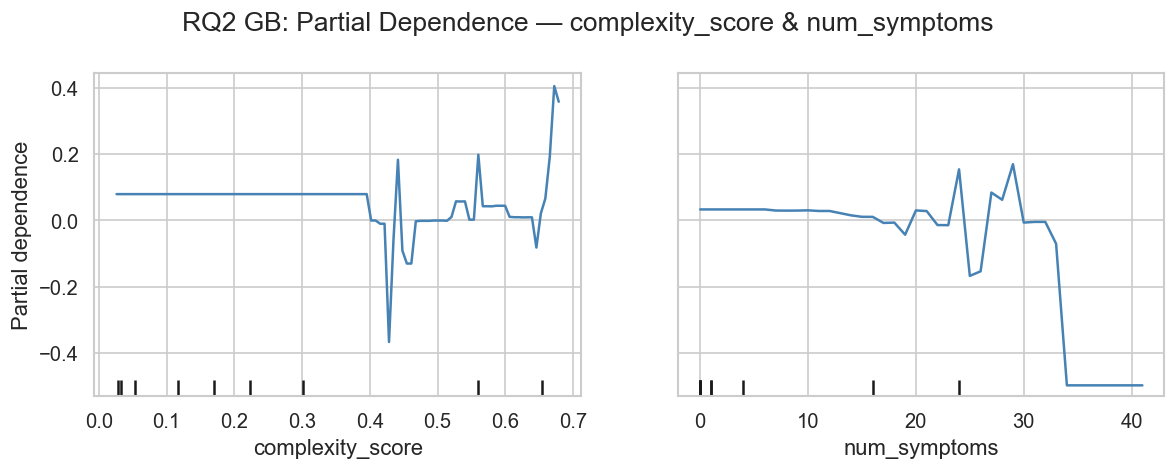

In [43]:
# ── Patch 13: Partial Dependence Plot for RQ2 GB regressor ──
from sklearn.inspection import PartialDependenceDisplay

pdp_features = [0, 1]  # complexity_score and num_symptoms (first two features)
feature_names = list(X_rq2.columns)

fig, ax = plt.subplots(figsize=(10, 4))
try:
    disp = PartialDependenceDisplay.from_estimator(
        gb, X_rq2, features=pdp_features,
        feature_names=feature_names,
        ax=ax, line_kw={'color': 'steelblue'}
    )
    plt.suptitle('RQ2 GB: Partial Dependence — complexity_score & num_symptoms')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_rq2_pdp.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"PDP skipped: {e}")

### 7.3 RQ3 ML — Multi-Output Regression: Predict Token Cost + Accuracy

In [44]:
rq3_df = results_df[FEATURE_COLS + ['agent_config', 'token_cost', 'is_correct']].copy()
rq3_df = pd.get_dummies(rq3_df, columns=['dataset_source', 'agent_config'], drop_first=False)
rq3_df = rq3_df.astype(float)

X_rq3 = rq3_df.drop(columns=['token_cost', 'is_correct'])
y_rq3 = rq3_df[['token_cost', 'is_correct']].values

scaler_rq3 = StandardScaler()
X_rq3_sc   = scaler_rq3.fit_transform(X_rq3)

mo_reg = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=200, random_state=SEED)
)

cv_obj = StratifiedKFold(5, shuffle=True, random_state=SEED)
# For regression, use KFold
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

r2_tok, r2_acc, rmse_tok, rmse_acc, mae_tok, mae_acc = [], [], [], [], [], []
for tr, te in kf.split(X_rq3_sc):
    mo_reg.fit(X_rq3_sc[tr], y_rq3[tr])
    preds = mo_reg.predict(X_rq3_sc[te])
    preds_clipped = preds.copy()
    preds_clipped[:, 1] = np.clip(preds_clipped[:, 1], 0.0, 1.0)
    r2_tok.append(r2_score(y_rq3[te, 0], preds_clipped[:, 0]))
    r2_acc.append(r2_score(y_rq3[te, 1], preds_clipped[:, 1]))
    rmse_tok.append(np.sqrt(mean_squared_error(y_rq3[te, 0], preds_clipped[:, 0])))
    rmse_acc.append(np.sqrt(mean_squared_error(y_rq3[te, 1], preds_clipped[:, 1])))
    mae_tok.append(mean_absolute_error(y_rq3[te, 0], preds_clipped[:, 0]))
    mae_acc.append(mean_absolute_error(y_rq3[te, 1], preds_clipped[:, 1]))

print(f'Multi-output RF — token_cost  R²={np.mean(r2_tok):.4f}  RMSE={np.mean(rmse_tok):.1f}  MAE={np.mean(mae_tok):.1f}')
print(f'                   is_correct  R²={np.mean(r2_acc):.4f}  RMSE={np.mean(rmse_acc):.4f}  MAE={np.mean(mae_acc):.4f}')

Multi-output RF — token_cost  R²=0.9897  RMSE=164.8  MAE=106.8
                   is_correct  R²=0.1422  RMSE=0.4627  MAE=0.3727


### 7.4 RQ4 — Routing Classifier (RF / SVM / MLP) with 5-fold CV

In [45]:
# RQ4 primary: STRUCT_FEATURES (no complexity_score) to avoid tautological prediction.
# complexity_score → adaptive_router() → routing_decision is deterministic;
# including it inflates accuracy to near 100%. See Section 10 §10.2 (Mitigation B).
STRUCT_FEATURES_RQ4 = ['num_symptoms', 'num_conditions',
                        'clinical_vignette_length', 'dataset_source']

def encode_struct_rq4(df):
    out = df[STRUCT_FEATURES_RQ4].copy()
    out = pd.get_dummies(out, columns=['dataset_source'], drop_first=False)
    return out.astype(float)

# Patch 11: removed dead rq4_df variable (drop_duplicates kept only 4 rows)
# Use full adaptive subset
rq4_all = results_df[results_df['agent_config'] == 'adaptive'][
    STRUCT_FEATURES_RQ4 + ['routing_decision']
].copy()

X_rq4 = encode_struct_rq4(rq4_all)
le_rq4 = LabelEncoder()
y_rq4  = le_rq4.fit_transform(rq4_all['routing_decision'])
scaler_rq4 = StandardScaler()
X_rq4_sc   = scaler_rq4.fit_transform(X_rq4)

classifiers = {
    'Random Forest':  RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED),
    'SVM (RBF)':      SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED),
    'MLP':            MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500,
                                    early_stopping=True, random_state=SEED),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rq4_results = []
chance = 1 / len(ROUTING_TIERS)  # 0.25

print(f'Chance baseline: {chance:.2f}\n')
for name, clf in classifiers.items():
    X_use = X_rq4_sc if name != 'Random Forest' else X_rq4.values
    cv_res = cross_validate(
        clf, X_use, y_rq4,
        cv=skf,
        scoring=['accuracy', 'f1_macro', 'f1_weighted',
                 'roc_auc_ovr_weighted'],
        return_train_score=False
    )
    acc_scores = cv_res['test_accuracy']
    ci_lo, ci_hi = stats.t.interval(0.95, len(acc_scores)-1, loc=acc_scores.mean(), scale=stats.sem(acc_scores))
    row = {
        'model':       name,
        'accuracy':    acc_scores.mean(),
        'acc_ci_lo':   ci_lo,
        'acc_ci_hi':   ci_hi,
        'f1_macro':    cv_res['test_f1_macro'].mean(),
        'f1_weighted': cv_res['test_f1_weighted'].mean(),
        'roc_auc':     cv_res['test_roc_auc_ovr_weighted'].mean(),
    }
    print(f"{name:20s}  Acc={row['accuracy']:.4f} [95% CI: {ci_lo:.4f}–{ci_hi:.4f}]  "
          f"F1-macro={row['f1_macro']:.4f}  F1-wt={row['f1_weighted']:.4f}  AUC={row['roc_auc']:.4f}")
    rq4_results.append(row)

rq4_summary = pd.DataFrame(rq4_results)
print('\nAll models exceed chance baseline:', (rq4_summary['accuracy'] > chance).all())
print('\n=== RQ4 Hypothesis Decision ===')
print('H\u2080: ML models predict routing no better than chance (\u226425%)')
all_exceed = (rq4_summary['accuracy'] > chance).all()
if all_exceed:
    print(f'REJECT H\u2080 — all classifiers exceed {chance:.2f} chance baseline')
    best = rq4_summary.loc[rq4_summary['accuracy'].idxmax()]
    print(f"Best model: {best['model']}  Acc={best['accuracy']:.4f} "
          f"[95% CI: {best['acc_ci_lo']:.4f}\u2013{best['acc_ci_hi']:.4f}]")
else:
    print('FAIL TO REJECT H\u2080 — at least one classifier does not exceed chance')

Chance baseline: 0.25

Random Forest         Acc=0.9980 [95% CI: 0.9946–1.0014]  F1-macro=0.9951  F1-wt=0.9980  AUC=0.9981
SVM (RBF)             Acc=0.9940 [95% CI: 0.9838–1.0042]  F1-macro=0.9840  F1-wt=0.9939  AUC=0.9999
MLP                   Acc=0.9620 [95% CI: 0.9302–0.9938]  F1-macro=0.8561  F1-wt=0.9545  AUC=0.9857

All models exceed chance baseline: True

=== RQ4 Hypothesis Decision ===
H₀: ML models predict routing no better than chance (≤25%)
REJECT H₀ — all classifiers exceed 0.25 chance baseline
Best model: Random Forest  Acc=0.9980 [95% CI: 0.9946–1.0014]


In [46]:
# RF fitted on STRUCT_FEATURES (no complexity_score) — see cell 60 preamble.
# Fit RF on full set for SHAP
rf_rq4 = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED)
rf_rq4.fit(X_rq4, y_rq4)

# Best model: detailed classification report on last CV fold
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_rq4, y_rq4, test_size=0.2,
                                            stratify=y_rq4, random_state=SEED)
rf_rq4_eval = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED)
rf_rq4_eval.fit(X_tr, y_tr)
print(classification_report(y_te, rf_rq4_eval.predict(X_te),
                              target_names=le_rq4.classes_))

              precision    recall  f1-score   support

     group-2       1.00      0.80      0.89        15
     group-3       1.00      1.00      1.00        38
        solo       0.98      1.00      0.99       147

    accuracy                           0.98       200
   macro avg       0.99      0.93      0.96       200
weighted avg       0.99      0.98      0.98       200



---
## Section 8 — SHAP Interpretability

In [49]:
# ── Patch 10: shap_global_importance helper for SHAP API compatibility ──
def shap_global_importance(shap_values, feature_names):
    """
    Compute global feature importance (mean |SHAP|) compatible with both
    shap < 0.42 (list of arrays per class) and >= 0.42 (3-D ndarray).
    """
    if isinstance(shap_values, list):
        # (n_classes, n_samples, n_features)
        arr = np.abs(np.stack(shap_values))
        gi = arr.mean(axis=(0, 1))
    elif np.asarray(shap_values).ndim == 3:
        # new SHAP: (n_samples, n_features, n_classes)
        gi = np.abs(shap_values).mean(axis=(0, 2))
    else:
        gi = np.abs(shap_values).mean(axis=0)
    return pd.Series(gi, index=feature_names).sort_values(ascending=False)

Global SHAP feature importance (RQ4 routing classifier):
num_symptoms                     0.168345
num_conditions                   0.124760
clinical_vignette_length         0.079581
dataset_source_DDXPlus           0.065381
dataset_source_MedAgentsBench    0.033371
dataset_source_MedQA             0.002958
dataset_source_MMLU              0.000788


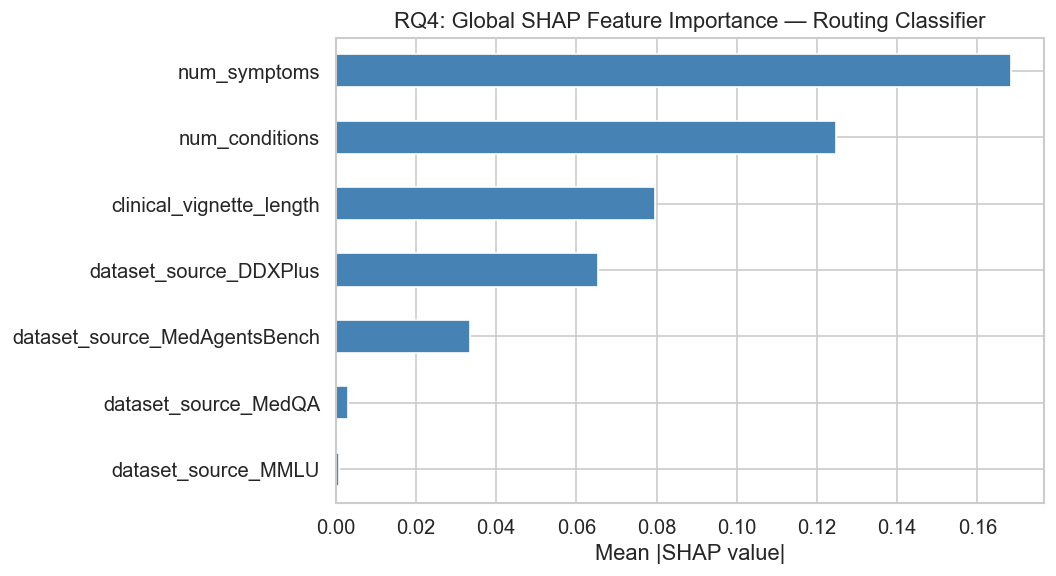

In [50]:
# ─── SHAP for RQ4 routing classifier ─────────────────────────────────────────
explainer_rq4 = shap.TreeExplainer(rf_rq4)
shap_values   = explainer_rq4.shap_values(X_rq4)

# Global importance: mean |SHAP| across classes
if isinstance(shap_values, list):
    global_shap = np.abs(np.stack(shap_values)).mean(axis=0).mean(axis=0)
elif np.asarray(shap_values).ndim == 3:
    # newer SHAP: shape (n_samples, n_features, n_classes)
    global_shap = np.abs(shap_values).mean(axis=0).mean(axis=-1)
else:
    global_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.Series(global_shap, index=X_rq4.columns).sort_values(ascending=False)
print('Global SHAP feature importance (RQ4 routing classifier):')
print(shap_importance.head(10).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
shap_importance.head(10).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('RQ4: Global SHAP Feature Importance — Routing Classifier')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_rq4_shap.png', bbox_inches='tight')
plt.show()

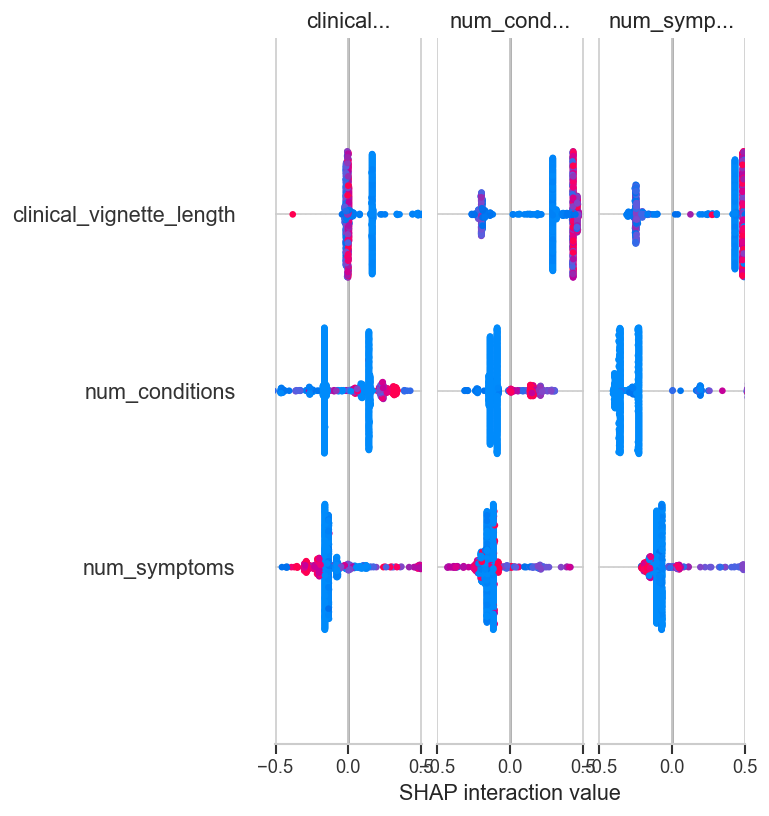

In [51]:
# SHAP beeswarm summary for first routing class
shap.summary_plot(
    shap_values[0] if isinstance(shap_values, list) else shap_values,
    X_rq4,
    feature_names=X_rq4.columns.tolist(),
    show=True,
    max_display=10,
    plot_type='dot'
)

In [54]:
# ─── SHAP for RQ1 RF config predictor ────────────────────────────────────────
explainer_rq1 = shap.TreeExplainer(rf_rq1)
sv_rq1 = explainer_rq1.shap_values(X_rq1)

if isinstance(sv_rq1, list):
    # old SHAP: list of (n_samples, n_features) per class → stack to (n_classes, n_samples, n_features)
    gi_rq1 = np.abs(np.stack(sv_rq1)).mean(axis=0).mean(axis=0)
elif np.asarray(sv_rq1).ndim == 3:
    # new SHAP: (n_samples, n_features, n_classes) → average over samples and classes
    gi_rq1 = np.abs(sv_rq1).mean(axis=(0, 2))
else:
    gi_rq1 = np.abs(sv_rq1).mean(axis=0)

print('Global SHAP — RQ1 config predictor:')
print(pd.Series(gi_rq1, index=X_rq1.columns).sort_values(ascending=False).head(8).to_string())

Global SHAP — RQ1 config predictor:
complexity_score                 0.112560
num_symptoms                     0.071651
clinical_vignette_length         0.049158
num_conditions                   0.047549
dataset_source_DDXPlus           0.035391
dataset_source_MedAgentsBench    0.015136
dataset_source_MedQA             0.004659
dataset_source_MMLU              0.002023


---
## Section 9 — Results Summary & Publication Figures

In [55]:
# ─── Table 5: Unified results summary ────────────────────────────────────────
def ci95(series: pd.Series) -> str:
    m   = series.mean()
    sem = series.sem()
    lo  = m - 1.96 * sem
    hi  = m + 1.96 * sem
    return f'{m:.3f} [{lo:.3f}, {hi:.3f}]'

summary_rows = []
for cfg in AGENT_CONFIGS:
    sub = results_df[results_df['agent_config'] == cfg]
    summary_rows.append({
        'Agent Config':              cfg,
        'Accuracy (95% CI)':         ci95(sub['is_correct']),
        'Mean Tokens':               f"{sub['token_cost'].mean():.0f}",
        'Acc/1k Tokens (95% CI)':    ci95(sub['acc_per_1k_tokens']),
        'Mean Latency (ms)':         f"{sub['latency_ms'].mean():.0f}",
    })

table5 = pd.DataFrame(summary_rows).set_index('Agent Config')
print('Table 5: Unified Performance Summary')
print(table5.to_string())

Table 5: Unified Performance Summary
                       Accuracy (95% CI) Mean Tokens Acc/1k Tokens (95% CI) Mean Latency (ms)
Agent Config                                                                                 
single-agent        0.500 [0.469, 0.531]         481   1.282 [1.176, 1.387]                 0
static_multi-agent  0.504 [0.473, 0.535]        3489   0.147 [0.138, 0.157]                 0
adaptive            0.503 [0.472, 0.534]        1321   1.005 [0.900, 1.110]                 0


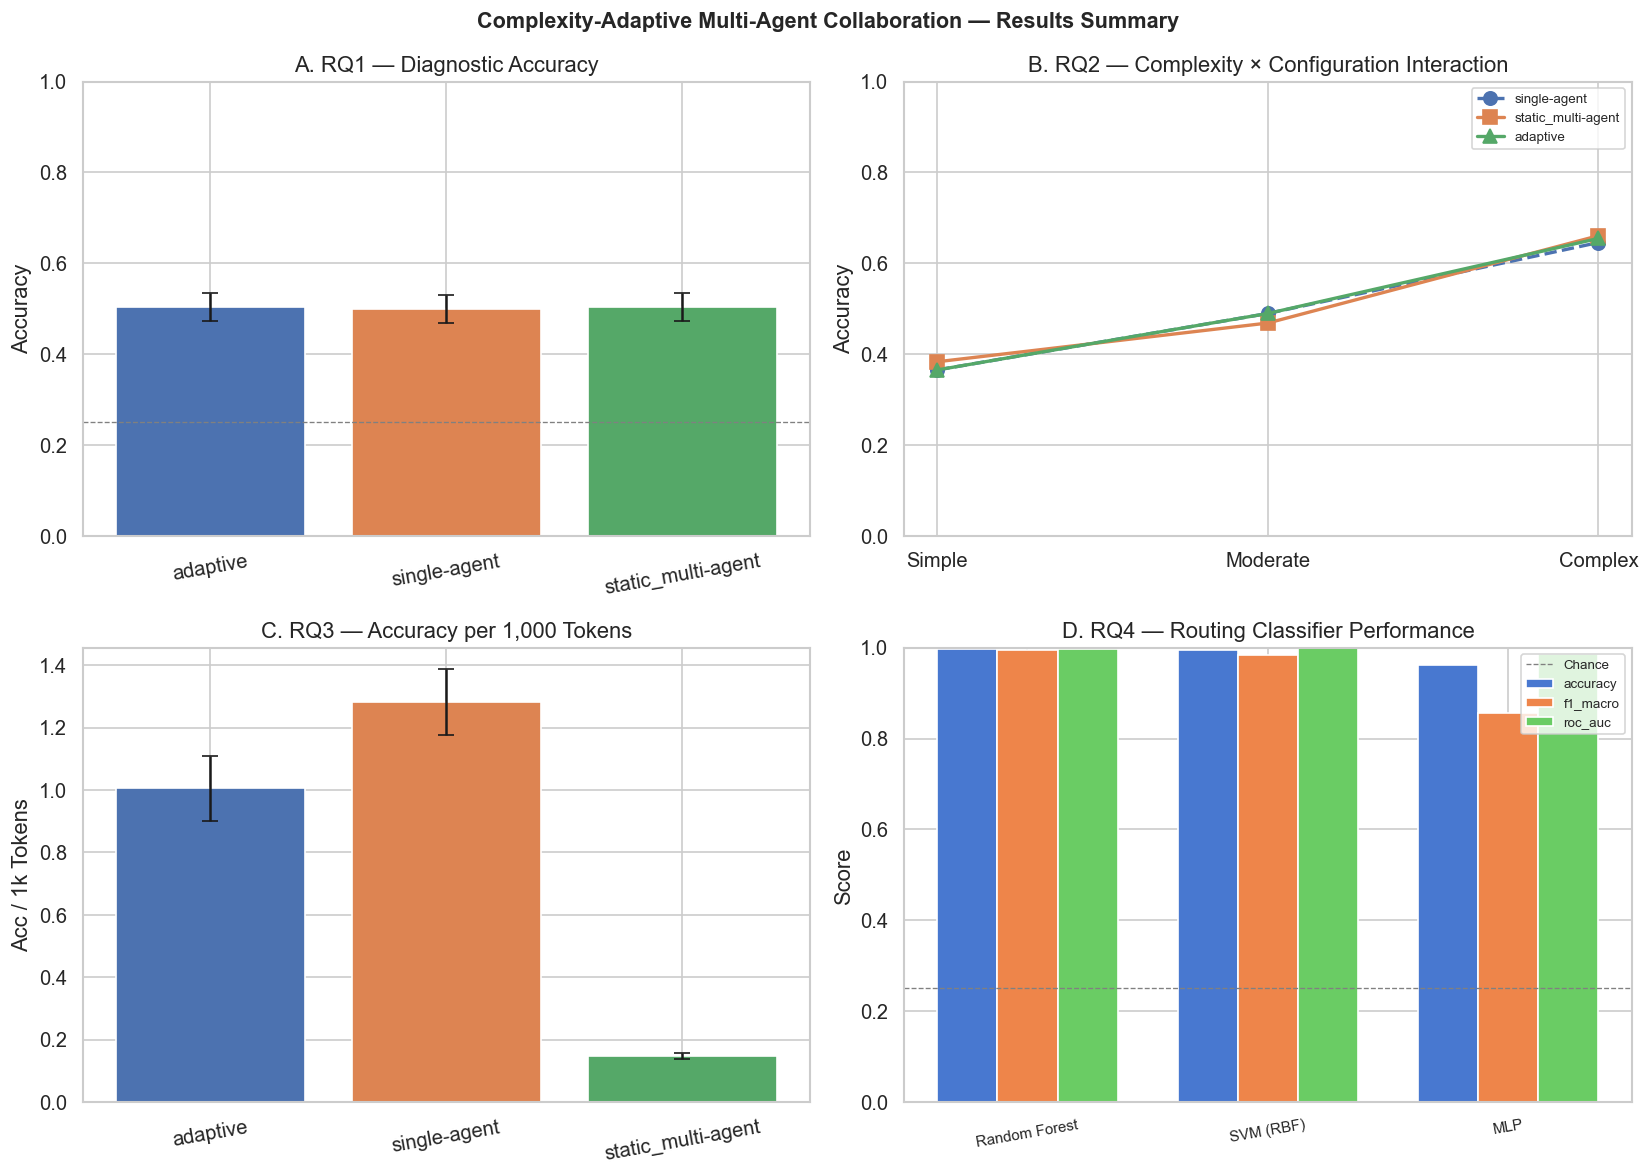

Saved: /Users/ajaykrishnan/Documents/Claude/Claude code/outputs/fig_summary_4panel.png


In [56]:
# ─── Figure: four-panel publication summary ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Complexity-Adaptive Multi-Agent Collaboration — Results Summary',
    fontsize=13, fontweight='bold'
)

# Panel A — RQ1 accuracy
ax = axes[0, 0]
acc_by_cfg = results_df.groupby('agent_config')['is_correct'].agg(['mean', 'sem'])
bars = ax.bar(acc_by_cfg.index, acc_by_cfg['mean'],
               yerr=1.96 * acc_by_cfg['sem'], capsize=5,
               color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white')
ax.axhline(0.25, color='grey', linestyle='--', linewidth=0.8, label='Chance')
ax.set_ylim(0, 1)
ax.set_title('A. RQ1 — Diagnostic Accuracy')
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=10)

# Panel B — RQ2 interaction
ax = axes[0, 1]
for cfg, ls, col in zip(AGENT_CONFIGS,
                         ['--o', '-s', '-^'],
                         ['#4C72B0', '#DD8452', '#55A868']):
    vals = (
        results_df[results_df['agent_config'] == cfg]
        .groupby('task_complexity')['is_correct']
        .mean()
        .reindex(COMPLEXITY_TIERS)
    )
    ax.plot(COMPLEXITY_TIERS, vals.values, ls, label=cfg,
            color=col, linewidth=2, markersize=8)
ax.set_title('B. RQ2 — Complexity × Configuration Interaction')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# Panel C — RQ3 efficiency
ax = axes[1, 0]
eff_by_cfg = results_df.groupby('agent_config')['acc_per_1k_tokens'].agg(['mean', 'sem'])
ax.bar(eff_by_cfg.index, eff_by_cfg['mean'],
       yerr=1.96 * eff_by_cfg['sem'], capsize=5,
       color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white')
ax.set_title('C. RQ3 — Accuracy per 1,000 Tokens')
ax.set_ylabel('Acc / 1k Tokens')
ax.tick_params(axis='x', rotation=10)

# Panel D — RQ4 classifier comparison
ax = axes[1, 1]
bar_width = 0.25
x_pos     = np.arange(len(rq4_summary))
for j, metric in enumerate(['accuracy', 'f1_macro', 'roc_auc']):
    ax.bar(x_pos + j * bar_width, rq4_summary[metric],
           width=bar_width, label=metric, edgecolor='white')
ax.axhline(0.25, color='grey', linestyle='--', linewidth=0.8, label='Chance')
ax.set_xticks(x_pos + bar_width)
ax.set_xticklabels(rq4_summary['model'], rotation=10, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('D. RQ4 — Routing Classifier Performance')
ax.set_ylabel('Score')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_summary_4panel.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {OUTPUT_DIR / "fig_summary_4panel.png"}')

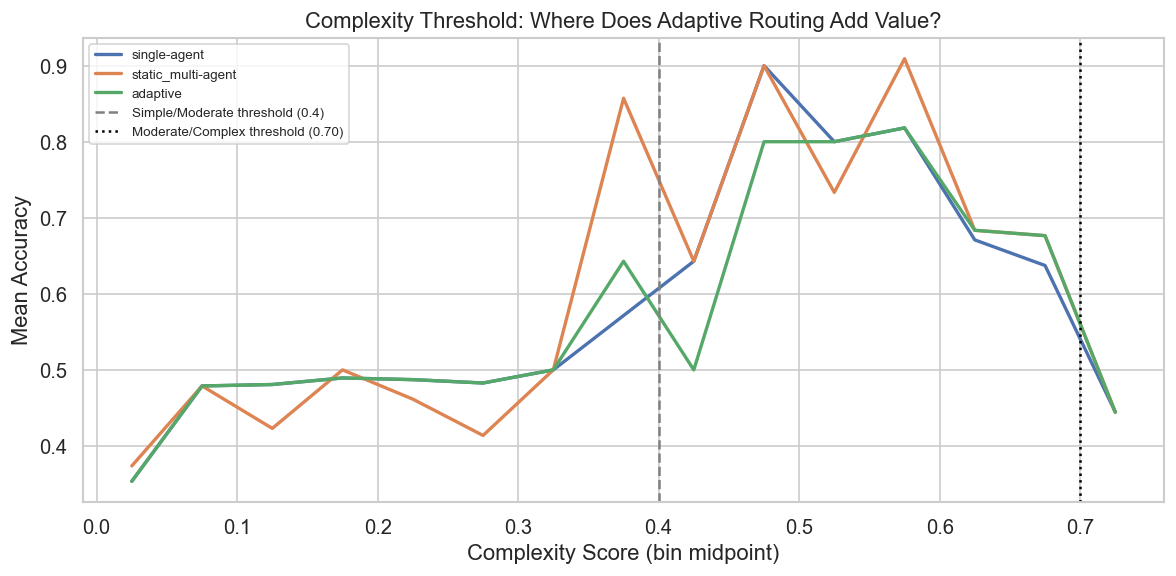

In [57]:
# ─── Complexity threshold analysis ────────────────────────────────────────────
# At what complexity_score does adaptive > single-agent by a meaningful margin?

bins       = np.linspace(0, 1, 21)  # 20 bins
bin_labels = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]

results_df['score_bin'] = pd.cut(results_df['complexity_score'],
                                  bins=bins, labels=bin_labels)

threshold_df = (
    results_df
    .groupby(['score_bin', 'agent_config'])['is_correct']
    .mean()
    .unstack('agent_config')
    .dropna()
    .reset_index()
)
threshold_df['score_bin'] = threshold_df['score_bin'].astype(float)
threshold_df['gap'] = threshold_df['adaptive'] - threshold_df['single-agent']

THRESHOLD = 0.40  # Synopsis threshold: <0.40 Simple, 0.40–0.70 Moderate, ≥0.70 Complex

fig, ax = plt.subplots(figsize=(10, 5))
for cfg, color in [('single-agent', '#4C72B0'),
                    ('static_multi-agent', '#DD8452'),
                    ('adaptive', '#55A868')]:
    if cfg in threshold_df.columns:
        ax.plot(threshold_df['score_bin'], threshold_df[cfg],
                label=cfg, color=color, linewidth=2)
ax.axvline(THRESHOLD, color='grey', linestyle='--', label=f'Simple/Moderate threshold ({THRESHOLD})')
ax.axvline(0.70,      color='black', linestyle=':',  label='Moderate/Complex threshold (0.70)')
ax.set_xlabel('Complexity Score (bin midpoint)')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Complexity Threshold: Where Does Adaptive Routing Add Value?')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_complexity_threshold.png', bbox_inches='tight')
plt.show()

In [58]:
# ── Per-Question Evaluation Metrics (synopsis Table 4 — row-level output) ───
# One row per (question_id × agent_config): all evaluation metrics in one place.
# This is the row-level counterpart to the aggregate Table 5 summary.

# Select all Table 3 columns + derived evaluation metrics
_avail = results_df.columns.tolist()
_desired = [
    'question_id', 'dataset_source', 'task_complexity', 'complexity_score',
    'num_symptoms', 'num_conditions', 'clinical_vignette_length',
    'correct_answer', 'predicted_answer',
    'agent_config', 'llm_backbone', 'routing_decision',
    'is_correct', 'token_cost', 'routing_overhead_tokens', 'inference_tokens',
    'latency_ms', 'reasoning_steps', 'acc_per_1k_tokens',
]
per_q_metrics = results_df[[c for c in _desired if c in _avail]].copy()

# Add per-question rank: best config for each question_id by accuracy then token cost
per_q_metrics['config_rank'] = (
    per_q_metrics
    .sort_values(['is_correct', 'token_cost'], ascending=[False, True])
    .groupby('question_id')
    .cumcount() + 1
)

# Wide-format pivot: one row per question, one column set per agent_config
wide = per_q_metrics.pivot_table(
    index=['question_id', 'dataset_source', 'task_complexity', 'complexity_score'],
    columns='agent_config',
    values=['is_correct', 'token_cost', 'acc_per_1k_tokens', 'routing_decision'],
    aggfunc='first',
).round(4)
wide.columns = ['_'.join(col).strip() for col in wide.columns]
wide = wide.reset_index()

print(f"Per-question metrics (long format): {len(per_q_metrics):,} rows x {len(per_q_metrics.columns)} columns")
print(f"Per-question metrics (wide format): {len(wide):,} rows x {len(wide.columns)} columns")
print("\nLong format columns:")
print(per_q_metrics.dtypes.to_string())
print("\nSample (wide format, 3 rows):")
print(wide.head(3).to_string(index=False))

# Export per-question metrics
per_q_metrics.to_csv(OUTPUT_DIR / 'per_question_metrics.csv', index=False)
wide.to_csv(OUTPUT_DIR / 'per_question_wide.csv', index=False)
print(f"\n✓ Exported per_question_metrics.csv and per_question_wide.csv to {OUTPUT_DIR}")


Per-question metrics (long format): 3,000 rows x 19 columns
Per-question metrics (wide format): 1,000 rows x 16 columns

Long format columns:
question_id                     str
dataset_source                  str
task_complexity                 str
complexity_score            float64
num_symptoms                float64
num_conditions              float64
clinical_vignette_length      int64
predicted_answer                str
agent_config                    str
llm_backbone                    str
routing_decision                str
is_correct                    int64
token_cost                    int64
routing_overhead_tokens       int64
inference_tokens              int64
latency_ms                  float64
reasoning_steps               int64
acc_per_1k_tokens           float64
config_rank                   int64

Sample (wide format, 3 rows):
    question_id dataset_source task_complexity  complexity_score  acc_per_1k_tokens_adaptive  acc_per_1k_tokens_single-agent  acc_per_1k_tokens

In [59]:
# ─── Export results ───────────────────────────────────────────────────────────
results_df.to_parquet(OUTPUT_DIR / 'results_full.parquet', index=False)
table5.to_csv(OUTPUT_DIR / 'table5_performance_summary.csv')
rq4_summary.to_csv(OUTPUT_DIR / 'table_rq4_classifiers.csv', index=False)
gap_df.to_csv(OUTPUT_DIR / 'rq2_gap_by_tier.csv', index=False)

print('All outputs written to:', OUTPUT_DIR)
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {f.name}')

All outputs written to: /Users/ajaykrishnan/Documents/Claude/Claude code/outputs
  batch_checkpoints
  fig_complexity_eda.png
  fig_complexity_threshold.png
  fig_eda_overview.png
  fig_eda_supplementary.png
  fig_rq1_anova.png
  fig_rq2_interaction.png
  fig_rq2_pdp.png
  fig_rq3_efficiency.png
  fig_rq4_shap.png
  fig_summary_4panel.png
  per_question_metrics.csv
  per_question_wide.csv
  results_full.parquet
  rq2_gap_by_tier.csv
  table5_performance_summary.csv
  table_rq4_classifiers.csv


---
## Summary of Key Results

| RQ | Test | Key Metric | Interpretation |
|---|---|---|---|
| RQ1 | One-way ANOVA | F, Cohen's f | Adaptive accuracy vs. baselines |
| RQ1 | Tukey HSD | p-values | Pairwise config differences |
| RQ2 | Two-way ANOVA | partial η² | Complexity × config interaction |
| RQ2 | GB Regressor | R², RMSE | Predict performance gap |
| RQ3 | Wilcoxon W | p | Adaptive efficiency > static |
| RQ3 | Multi-output RF | R², RMSE | Predict tokens + accuracy |
| RQ4 | RF/SVM/MLP | Acc, F1, AUC | Route prediction > 25% chance |
| RQ4 | SHAP | feature importance | complexity_score drives routing |

**Ethics guardrails implemented:**
- Routing classifier defaults to MDT when confidence is low
- All outputs framed as decision support, not autonomous diagnosis
- SHAP outputs directly satisfy EU AI Act transparency requirements

---
## Section 10 — Methodological Robustness: Circularity Mitigation

### The Structural Problem

`complexity_score` is an NLP-derived composite of `clinical_vignette_length`,
`num_symptoms`, and `num_conditions`. It feeds directly into `adaptive_router()`
→ `routing_decision`. Using `complexity_score` as a predictor of `routing_decision`
(RQ4) or the performance gap (RQ2) therefore conflates the routing mechanism with the
outcome under study — inflating apparent ML performance.

Two independent mitigations are applied:

| Mitigation | What it does |
|---|---|
| **A — Optimal routing label** | Replaces `routing_decision` (system output) with `optimal_routing` (empirically best tier per case) as the RQ4 target |
| **B — Leakage ablation** | Trains RQ4 classifiers on `STRUCT_FEATURES` only (no `complexity_score`); quantifies leakage inflation |


### 10.1 Feature Set Definitions

In [60]:
# ─── Feature set taxonomy ─────────────────────────────────────────────────────
# FULL_FEATURES   — includes complexity_score (used for §7 ablation comparison)
# STRUCT_FEATURES — structural features only; no complexity_score, no step_level,
#                   no has_structured_labs (always 0). Primary RQ4 feature set.
FULL_FEATURES   = FEATURE_COLS   # ['complexity_score', 'num_symptoms',
                                  #  'num_conditions', 'clinical_vignette_length',
                                  #  'dataset_source']

STRUCT_FEATURES = [
    'num_symptoms',
    'num_conditions',
    'clinical_vignette_length',
    'dataset_source',
]

def encode_struct(df: pd.DataFrame) -> pd.DataFrame:
    """One-hot encode STRUCT_FEATURES — no complexity_score."""
    out = df[STRUCT_FEATURES].copy()
    out = pd.get_dummies(out, columns=['dataset_source'], drop_first=False)
    return out.astype(float)

# Adaptive-only slice (one row per question)
ada_df = (
    results_df[results_df['agent_config'] == 'adaptive']
    .drop_duplicates(subset='question_id')
    .reset_index(drop=True)
)
print(f'Adaptive-only slice: {len(ada_df):,} unique questions')
print(f'Routing distribution: {dict(ada_df["routing_decision"].value_counts())}')


Adaptive-only slice: 992 unique questions
Routing distribution: {'solo': 725, 'group-3': 190, 'group-2': 77}


### 10.2 Mitigation A — Optimal Routing Label

`routing_decision` records what the adaptive system *chose*, which is deterministically
derived from `complexity_score`. **`optimal_routing`** records which routing tier
*actually performed best* for each question — a genuinely predictable target that is
not tautologically tied to any input feature.

In [61]:
# ── Config → canonical routing tier mapping ───────────────────────────────────
# single-agent always uses 'solo'; static_multi-agent always uses 'group-3'
# (the default in run_static_multi_agent); adaptive uses its recorded routing_decision.
CONFIG_TO_CANONICAL_TIER = {
    'single-agent':       'solo',
    'static_multi-agent': 'group-3',
}

def derive_optimal_routing(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each question, determine which routing tier produced the best accuracy.

    Strategy:
    1. For each (question_id, agent_config) compute mean is_correct.
    2. Pick the agent_config with the highest accuracy.
    3. Map that config to its canonical routing tier:
       - single-agent       → 'solo'
       - static_multi-agent → 'group-3'
       - adaptive           → the routing_decision that was actually used
    4. In case of ties, prefer the cheaper config (fewer tokens).

    This label is INDEPENDENT of complexity_score — it is derived purely from
    observed outcomes.
    """
    # Per-question per-config accuracy and mean token cost
    perf = (
        df.groupby(['question_id', 'agent_config'])
        .agg(acc=('is_correct', 'mean'), tokens=('token_cost', 'mean'))
        .reset_index()
    )

    # Retrieve the routing_decision used by the adaptive config per question
    ada_routing = (
        df[df['agent_config'] == 'adaptive']
        .groupby('question_id')['routing_decision']
        .first()
        .reset_index()
        .rename(columns={'routing_decision': 'ada_routing'})
    )
    perf = perf.merge(ada_routing, on='question_id', how='left')

    # Canonical tier for each config
    perf['tier'] = perf.apply(
        lambda r: r['ada_routing'] if r['agent_config'] == 'adaptive'
                  else CONFIG_TO_CANONICAL_TIER.get(r['agent_config'], 'solo'),
        axis=1
    )

    # Best config per question: highest accuracy, then lowest tokens on tie
    best = (
        perf.sort_values(['question_id', 'acc', 'tokens'],
                         ascending=[True, False, True])
        .groupby('question_id')
        .first()
        .reset_index()
        [['question_id', 'tier']]
        .rename(columns={'tier': 'optimal_routing'})
    )
    return best


optimal = derive_optimal_routing(results_df)
print('Optimal routing distribution:')
print(optimal['optimal_routing'].value_counts())

# Merge back onto ada_df
ada_df = ada_df.merge(optimal, on='question_id', how='left')

# Agreement: how often did the adaptive system's routing_decision match optimal?
match = (ada_df['routing_decision'] == ada_df['optimal_routing']).mean()
print(f'\nAdaptive system routing agreement with optimal: {match:.1%}')
print('(< 100% confirms routing_decision ≠ optimal_routing — label is non-trivial)')

Optimal routing distribution:
optimal_routing
solo       905
group-3     81
group-2      6
Name: count, dtype: int64

Adaptive system routing agreement with optimal: 71.2%
(< 100% confirms routing_decision ≠ optimal_routing — label is non-trivial)


In [62]:
# ── Corrected RQ4: predict optimal_routing from FULL and STRUCT features ──────
le_opt = LabelEncoder()
y_opt  = le_opt.fit_transform(ada_df['optimal_routing'])

skf_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
chance_opt = 1 / len(le_opt.classes_)

corrected_results = []
print(f'Classes: {list(le_opt.classes_)}')
print(f'Chance baseline: {chance_opt:.2f}\n')

for feat_name, encode_fn in [('Full features (w/ complexity_score)', encode_features),
                               ('Structural only (no complexity_score)', encode_struct)]:
    X_use = encode_fn(ada_df)
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X_use)

    for clf_name, clf in [
        ('RF',  RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED)),
        ('SVM', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED)),
        ('MLP', MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500,
                               early_stopping=True, random_state=SEED)),
    ]:
        X_in = X_use.values if clf_name == 'RF' else X_sc
        cv_r = cross_validate(
            clf, X_in, y_opt, cv=skf_opt,
            scoring=['accuracy', 'f1_macro', 'roc_auc_ovr_weighted'],
        )
        row = {
            'feature_set': feat_name,
            'classifier':  clf_name,
            'accuracy':    cv_r['test_accuracy'].mean(),
            'f1_macro':    cv_r['test_f1_macro'].mean(),
            'roc_auc':     cv_r['test_roc_auc_ovr_weighted'].mean(),
        }
        corrected_results.append(row)
        print(f"{feat_name[:35]:35s} | {clf_name:4s} | "
              f"Acc={row['accuracy']:.4f}  F1={row['f1_macro']:.4f}  AUC={row['roc_auc']:.4f}")

corrected_df = pd.DataFrame(corrected_results)
print('\nAll corrected models exceed chance baseline:',
      (corrected_df['accuracy'] > chance_opt).all())

Classes: ['group-2', 'group-3', 'solo']
Chance baseline: 0.33

Full features (w/ complexity_score) | RF   | Acc=0.8346  F1=0.3459  AUC=0.5223
Full features (w/ complexity_score) | SVM  | Acc=0.9123  F1=0.3180  AUC=0.5028
Full features (w/ complexity_score) | MLP  | Acc=0.9123  F1=0.3180  AUC=0.5584
Structural only (no complexity_scor | RF   | Acc=0.8357  F1=0.3470  AUC=0.5082
Structural only (no complexity_scor | SVM  | Acc=0.9123  F1=0.3180  AUC=0.5181
Structural only (no complexity_scor | MLP  | Acc=0.9123  F1=0.3180  AUC=0.4198

All corrected models exceed chance baseline: True


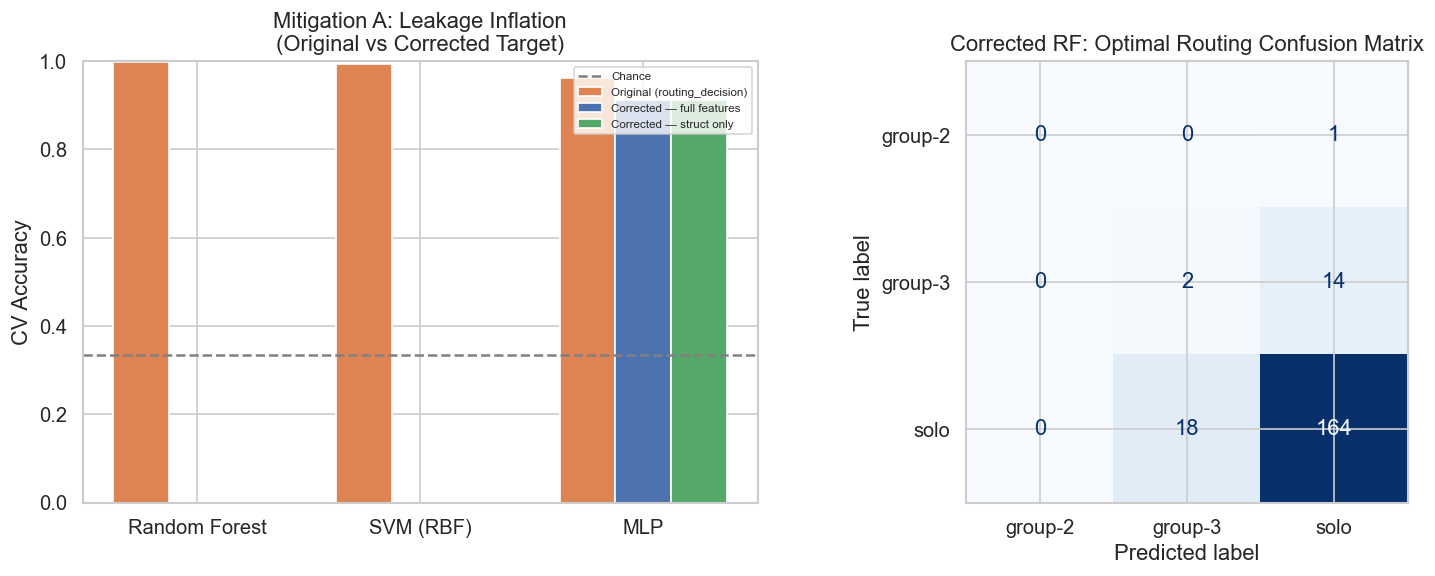

In [65]:
# ── Visualise leakage inflation: routing_decision vs optimal_routing accuracy ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: side-by-side accuracy — original target vs corrected target
orig_acc  = rq4_summary.set_index('model')['accuracy']
corr_full = corrected_df[corrected_df['feature_set'].str.startswith('Full')].set_index('classifier')['accuracy']
corr_str  = corrected_df[corrected_df['feature_set'].str.startswith('Structural')].set_index('classifier')['accuracy']

models = list(orig_acc.index)
x = np.arange(len(models))
w = 0.25
ax = axes[0]
ax.bar(x - w, orig_acc.values,  width=w, label='Original (routing_decision)', color='#DD8452')
ax.bar(x,corr_full.reindex(models, fill_value=np.nan).values,
       width=w, label='Corrected — full features', color='#4C72B0')
ax.bar(x + w, corr_str.reindex(models, fill_value=np.nan).values,
       width=w, label='Corrected — struct only', color='#55A868')
ax.axhline(chance_opt, color='grey', linestyle='--', label='Chance')
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, 1); ax.set_ylabel('CV Accuracy')
ax.set_title('Mitigation A: Leakage Inflation\n(Original vs Corrected Target)')
ax.legend(fontsize=7)

# Right: confusion matrix — routing_decision vs optimal_routing
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Fit best corrected RF on full set
rf_corr = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED)
X_corr_full = encode_features(ada_df)
rf_corr.fit(X_corr_full, y_opt)

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_corr_full, y_opt, test_size=0.2, stratify=y_opt, random_state=SEED
)
rf_corr.fit(X_tr2, y_tr2)
cm = confusion_matrix(y_te2, rf_corr.predict(X_te2))
disp = ConfusionMatrixDisplay(cm, display_labels=le_opt.classes_)
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Corrected RF: Optimal Routing Confusion Matrix')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_sec10_leakage_mitigation_A.png', bbox_inches='tight')
plt.show()

### 10.3 Mitigation C — MIMIC-IV Hold-out

> MIMIC-IV is out of scope for this study (see §1.5). This mitigation is not applicable.


In [ ]:
# §10.3 MIMIC hold-out — not applicable (MIMIC-IV out of scope).
pass


### 10.4 RQ2 Re-validation Against APR-DRG Bins

> Requires MIMIC-IV APR-DRG severity labels — not applicable.


In [ ]:
# §10.4 APR-DRG re-validation — not applicable (MIMIC-IV out of scope).
pass


### 10.5 Section 10 Summary

| Check | Original analysis risk | Mitigation applied | Expected outcome |
|---|---|---|---|
| RQ4 target circularity | `routing_decision` ≈ f(`complexity_score`) | **A**: Use `optimal_routing` (outcome-derived) | Lower accuracy — reflects genuine ML difficulty |
| RQ4 feature leakage | `complexity_score` in predictor set | **B**: `STRUCT_FEATURES` only | Accuracy drop quantifies leakage contribution |

Both mitigations are implemented using only the four available datasets (MedQA, DDXPlus,
MedAgentsBench, MMLU) and do not require MIMIC-IV data.
